# Pipeline nghiên cứu: StyleGAN2-ADA (có điều kiện) + DASS xử lý mất cân bằng lớp — Brain Tumor MRI

Phiên bản chuyển thể từ pipeline ISIC2016 sang bộ dữ liệu **Brain Tumor** có cấu trúc:

```
Brain_Tumor_Dataset/
├── Negative/   (ảnh không u)
└── Positive/   (ảnh có u)
```

## Khác biệt so với bản ISIC2016

| Nội dung | ISIC2016 | Bản này |
|---|---|---|
| Nhãn | File CSV ground truth | **Có sẵn theo thư mục**, không cần ghép nhãn |
| Tập test | Có sẵn, tách riêng | **Tự chia** train / val / test từ cùng một nguồn |
| Lớp thiểu số | Luôn là malignant | **Tự xác định** khi chạy (lớp nào ít ảnh train hơn) |
| Tiền xử lý | Crop viền tối | Crop nền đen + **đệm về ảnh vuông** (giữ tỉ lệ giải phẫu của MRI) |
| Biến thể | M0–M6 | Thêm **M7**: ảnh sinh có ở **cả hai lớp** (giảm rủi ro shortcut) |

## Toàn bộ thiết kế chống lỗi vẫn giữ nguyên

- **StyleGAN2-ADA bản chính thức NVlabs**, có điều kiện, train trên **toàn bộ tập train của cả hai lớp**.
- **Early stopping theo KID của lớp thiểu số**; dùng snapshot tốt nhất, không dùng snapshot cuối.
- Mọi ảnh lưu **PNG** (thật và sinh cùng định dạng, tránh shortcut theo độ nén).
- Classifier: augmentation, train 2 giai đoạn, early stopping theo **val AUC**.
- Ngưỡng quyết định chọn trên **val**, không chọn trên test.
- Nhiều seed (mean ± std) + **paired bootstrap ΔAUC** so với baseline.
- **Kiểm tra shortcut** (tách ảnh thật / ảnh sinh) và **hiển thị ảnh được chọn / bị loại**.
- Mọi checkpoint và kết quả lưu lên Drive; ngắt Colab thì chạy lại là tự resume.

## Về phiên bản thư viện
StyleGAN2-ADA gốc viết cho PyTorch 1.7–1.9. Colab hiện dùng Python 3.12/3.13, **không cài được PyTorch 1.x** (không có wheel),
nên notebook **vá (patch) mã nguồn** cho tương thích PyTorch 2.x:
- `dnnlib/util.py`: bỏ `distutils` (đã bị xóa khỏi Python 3.12).
- `grid_sample_gradfix`: **giữ** custom op (R1 penalty cần đạo hàm bậc 2 xuyên qua augmentation của ADA), sửa lời gọi `grid_sampler_2d_backward` theo chữ ký mới (thêm `output_mask`).
- `conv2d_gradfix`: tắt custom op, dùng conv2d chuẩn của PyTorch.
- `misc.py`: PyTorch ≥ 2.2 bỏ tham số `data_source` của `Sampler.__init__`.
- `custom_ops.py`: PyTorch ≥ 1.13 không còn đăng ký plugin vào `sys.modules` → lấy module từ giá trị trả về của `cpp_extension.load()`.
- `training_loop.py`: khôi phục xác suất ADA `p` khi resume.

**GPU khuyến nghị:** A100/L4. Ở 256×256, tốc độ thực tế khoảng 15 giây/kimg trên A100.

## 0. Cài đặt môi trường, tải StyleGAN2-ADA chính thức và vá tương thích

In [ ]:
import subprocess, sys, os, pathlib

SG2_REPO = "/content/stylegan2-ada-pytorch"

def sh(cmd, cwd=None):
    print("$", cmd)
    r = subprocess.run(cmd, shell=True, cwd=cwd, capture_output=True, text=True)
    if r.stdout.strip():
        print(r.stdout[-3000:])
    if r.returncode != 0:
        print(r.stderr[-3000:])
        raise RuntimeError(f"Lệnh lỗi: {cmd}")
    return r

sh(f"{sys.executable} -m pip install -q ninja click requests psutil scikit-learn scikit-image pandas tqdm")
if not os.path.isdir(SG2_REPO):
    sh(f"git clone -q https://github.com/NVlabs/stylegan2-ada-pytorch.git {SG2_REPO}")
# Đưa mã nguồn về nguyên bản trước khi vá -> chạy lại cell này bao nhiêu lần cũng cho cùng kết quả
sh("git checkout -q -- .", cwd=SG2_REPO)


def patch_file(rel_path, old, new):
    p = pathlib.Path(SG2_REPO) / rel_path
    s = p.read_text()
    if new in s:
        print(f"[patch] {rel_path}: đã vá trước đó")
        return
    if old not in s:
        raise RuntimeError(f"[patch] Không tìm thấy đoạn cần vá trong {rel_path}")
    p.write_text(s.replace(old, new, 1))
    print(f"[patch] {rel_path}: OK")


# (1) Python 3.12 đã xóa distutils
patch_file(
    "dnnlib/util.py",
    "from distutils.util import strtobool",
    "def strtobool(val):  # [PATCH] replaces distutils.util.strtobool (removed in Python 3.12)\n"
    "    val = str(val).lower()\n"
    "    if val in ('y', 'yes', 't', 'true', 'on', '1'):\n"
    "        return 1\n"
    "    if val in ('n', 'no', 'f', 'false', 'off', '0'):\n"
    "        return 0\n"
    "    raise ValueError(f'invalid truth value {val!r}')",
)

# (2) Custom op gradfix chỉ hỗ trợ PyTorch 1.7-1.9 -> dùng op chuẩn của PyTorch 2.x
# grid_sample: KHÔNG được tắt custom op này. R1 penalty cần đạo hàm bậc 2 xuyên qua grid_sample của
# ADA, mà PyTorch chưa hỗ trợ ("derivative for aten::grid_sampler_2d_backward is not implemented").
# -> Giữ custom op, chỉ sửa lời gọi op cho đúng chữ ký mới của PyTorch >= 1.11 (thêm output_mask).
patch_file(
    "torch_utils/ops/grid_sample_gradfix.py",
    "    if any(torch.__version__.startswith(x) for x in ['1.7.', '1.8.', '1.9']):\n        return True\n",
    "    return True  # [PATCH] custom op made compatible with PyTorch 2.x (needed for R1 through ADA)\n",
)
patch_file(
    "torch_utils/ops/grid_sample_gradfix.py",
    "        op = torch._C._jit_get_operation('aten::grid_sampler_2d_backward')\n"
    "        grad_input, grad_grid = op(grad_output, input, grid, 0, 0, False)\n",
    "        # [PATCH] PyTorch>=1.11: grid_sampler_2d_backward requires output_mask\n"
    "        grad_input, grad_grid = torch.ops.aten.grid_sampler_2d_backward(grad_output, input, grid, 0, 0, False, [True, True])\n",
)
patch_file(
    "torch_utils/ops/conv2d_gradfix.py",
    "def _should_use_custom_op(input):\n",
    "def _should_use_custom_op(input):\n    return False  # [PATCH] PyTorch 2.x: use torch.nn.functional.conv2d\n",
)

# (3) Khôi phục xác suất augmentation ADA khi resume (bản gốc reset p=0)
patch_file(
    "training/training_loop.py",
    "        augment_pipe.p.copy_(torch.as_tensor(augment_p))\n",
    "        augment_pipe.p.copy_(torch.as_tensor(augment_p))\n"
    "        if ('resume_data' in locals()) and (resume_data.get('augment_pipe', None) is not None):  # [PATCH]\n"
    "            augment_pipe.p.copy_(resume_data['augment_pipe'].p.to(device))\n"
    "            print(f'[PATCH] Restored ADA p = {float(augment_pipe.p):.3f} from resume pickle')\n",
)

# (4) PyTorch >= 1.13: cpp_extension.load() trả về module nhưng KHÔNG đăng ký vào sys.modules
#     -> importlib.import_module() của code gốc báo "No module named 'bias_act_plugin'" dù đã biên dịch xong
patch_file(
    "torch_utils/custom_ops.py",
    "            torch.utils.cpp_extension.load(name=module_name, build_directory=build_dir,",
    "            module = torch.utils.cpp_extension.load(name=module_name, build_directory=build_dir,",
)
patch_file(
    "torch_utils/custom_ops.py",
    "            torch.utils.cpp_extension.load(name=module_name, verbose=verbose_build, sources=sources, **build_kwargs)",
    "            module = torch.utils.cpp_extension.load(name=module_name, verbose=verbose_build, sources=sources, **build_kwargs)",
)
patch_file(
    "torch_utils/custom_ops.py",
    "        module = importlib.import_module(module_name)\n",
    "        # [PATCH] PyTorch>=1.13: use the module returned by load() (no longer registered in sys.modules)\n",
)

# (5) PyTorch >= 2.2: torch.utils.data.Sampler.__init__ không còn nhận tham số data_source
patch_file(
    "torch_utils/misc.py",
    "        super().__init__(dataset)\n",
    "        super().__init__()  # [PATCH] PyTorch>=2.2: Sampler.__init__ no longer takes data_source\n",
)

# Kiểm tra biên dịch CUDA plugin (True = plugin CUDA; False = bản tham chiếu, vẫn đúng nhưng chậm)
sh(f"""{sys.executable} -c "
import torch, warnings
from torch_utils.ops import bias_act, upfirdn2d
print('torch', torch.__version__, '| CUDA', torch.version.cuda, '| GPU', torch.cuda.get_device_name(0))
print('bias_act CUDA plugin:', bias_act._init())
print('upfirdn2d CUDA plugin:', upfirdn2d._init())
" """, cwd=SG2_REPO)

$ /usr/bin/python3 -m pip install -q ninja click requests psutil scikit-learn scikit-image pandas tqdm
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 183.4/183.4 kB 16.7 MB/s eta 0:00:00

$ git clone -q https://github.com/NVlabs/stylegan2-ada-pytorch.git /content/stylegan2-ada-pytorch
$ git checkout -q -- .
[patch] dnnlib/util.py: OK
[patch] torch_utils/ops/grid_sample_gradfix.py: OK
[patch] torch_utils/ops/grid_sample_gradfix.py: OK
[patch] torch_utils/ops/conv2d_gradfix.py: OK
[patch] training/training_loop.py: OK
[patch] torch_utils/custom_ops.py: OK
[patch] torch_utils/custom_ops.py: OK
[patch] torch_utils/custom_ops.py: OK
[patch] torch_utils/misc.py: OK
$ /usr/bin/python3 -c "
import torch, warnings
from torch_utils.ops import bias_act, upfirdn2d
print('torch', torch.__version__, '| CUDA', torch.version.cuda, '| GPU', torch.cuda.get_device_name(0))
print('bias_act CUDA plugin:', bias_act._init())
print('upfirdn2d CUDA plugin:', upfirdn2d._init())
" 
torch 2.11.0+cu128 | CUDA 12.8 | 

CompletedProcess(args='/usr/bin/python3 -c "\nimport torch, warnings\nfrom torch_utils.ops import bias_act, upfirdn2d\nprint(\'torch\', torch.__version__, \'| CUDA\', torch.version.cuda, \'| GPU\', torch.cuda.get_device_name(0))\nprint(\'bias_act CUDA plugin:\', bias_act._init())\nprint(\'upfirdn2d CUDA plugin:\', upfirdn2d._init())\n" ', returncode=0, stdout='torch 2.11.0+cu128 | CUDA 12.8 | GPU NVIDIA A100-SXM4-80GB\nSetting up PyTorch plugin "bias_act_plugin"... Done.\nbias_act CUDA plugin: True\nSetting up PyTorch plugin "upfirdn2d_plugin"... Done.\nupfirdn2d CUDA plugin: True\n', stderr='')

In [ ]:
import gc, json, time, glob, shutil, random, zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from PIL import Image

import tensorflow as tf
# BẮT BUỘC: TF mặc định chiếm toàn bộ VRAM -> StyleGAN2-ADA (PyTorch) sẽ hết bộ nhớ
for _gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(_gpu, True)
from tensorflow.keras import layers

import torch

from google.colab import drive
drive.mount("/content/drive")

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
torch.manual_seed(SEED)

print("TensorFlow:", tf.__version__, "| PyTorch:", torch.__version__)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "KHÔNG CÓ GPU")

Mounted at /content/drive
TensorFlow: 2.20.0 | PyTorch: 2.11.0+cu128
GPU: NVIDIA A100-SXM4-80GB


## 1. Cấu hình (CFG)

In [ ]:
class CFG:
    # ---- Dữ liệu gốc trên Drive: DATA_DIR/<Negative|Positive>/*.png|jpg ----
    DATA_DIR = "/content/drive/MyDrive/Colab Notebooks/ColabData/Brain_Tumor_Dataset"
    FOLDER_TO_CLASS = {"Negative": "negative", "Positive": "positive"}   # tên thư mục -> tên lớp
    CLASS_TO_IDX = {"negative": 0, "positive": 1}                        # positive = có u = lớp dương tính

    # ---- Nơi lưu kết quả trên Drive ----
    DRIVE_ROOT = "/content/drive/MyDrive/Colab Notebooks/ColabData/BrainTumor_GAN"
    DRIVE_RESULTS_DIR = f"{DRIVE_ROOT}/results_bt"
    DRIVE_GAN_DIR     = f"{DRIVE_ROOT}/checkpoints_bt/stylegan2ada"
    DRIVE_PRED_DIR    = f"{DRIVE_ROOT}/results_bt/predictions"
    DRIVE_CLF_DIR     = f"{DRIVE_ROOT}/checkpoints_bt/classifiers"
    DRIVE_DATA_DIR    = f"{DRIVE_ROOT}/checkpoints_bt/data"

    # ---- Local Colab ----
    IMG_SIZE = 256
    LOCAL_ROOT       = "/content/local_data_bt"
    LOCAL_RAW        = f"{LOCAL_ROOT}/raw"
    LOCAL_PP         = f"{LOCAL_ROOT}/pp{IMG_SIZE}_png"        # toàn bộ ảnh đã tiền xử lý, theo lớp
    LOCAL_TEST_PP    = f"{LOCAL_ROOT}/test{IMG_SIZE}_png"      # ảnh test (tách ra từ LOCAL_PP)
    LOCAL_GAN_DATASET = f"{LOCAL_ROOT}/gan_dataset/brain_tumor_train_cond_{IMG_SIZE}.zip"
    LOCAL_GAN_RUNS   = f"{LOCAL_ROOT}/gan_runs"
    LOCAL_CANDIDATES = f"{LOCAL_ROOT}/candidates_bt"
    LOCAL_VARIANTS   = f"{LOCAL_ROOT}/variants_bt"
    LOCAL_CLF_CKPT   = f"{LOCAL_ROOT}/classifier_ckpt_bt"

    # ---- Chia train / val / test (tự chia, phân tầng theo lớp) ----
    TEST_FRACTION = 0.15
    VAL_FRACTION = 0.176         # tính trên PHẦN CÒN LẠI sau khi tách test -> 70 / 15 / 15
    CROP_BORDER = False          # True: crop nền đen quanh đầu trước khi đệm vuông (xem Bước 2)
    # Nếu nhiều ảnh cùng một bệnh nhân (ví dụ nhiều lát cắt), đặt regex lấy mã bệnh nhân từ TÊN FILE
    # để chia theo nhóm, tránh rò rỉ giữa train và test. Ví dụ: r"^(P\d+)_" cho "P017_slice12.png".
    GROUP_REGEX = None

    # ---- StyleGAN2-ADA ----
    SG2_REPO = SG2_REPO
    GAN_CFG = "paper256"
    GAN_BATCH = 16
    GAN_GAMMA = 1.0
    GAN_MIRROR = True            # MRI não gần đối xứng trái-phải -> lật ngang hợp lý
    GAN_AUG_TARGET = 0.6
    GAN_MAX_KIMG = 3000
    GAN_KIMG_PER_SNAP = 100
    GAN_MIN_KIMG = 400
    GAN_PATIENCE = 5
    GAN_MIN_REL_DELTA = 0.02
    KID_N_GEN = 1000
    KID_SUBSETS = 50
    KID_SEED = 123
    GEN_SEED = 777
    TRUNC_PSI = 1.0
    MINORITY_IDX = None          # gán tự động sau khi chia dữ liệu
    MAJORITY_IDX = None

    # ---- Lọc ảnh sinh ----
    K_VALUES = [1.0, 1.5, 2.0, 3.0]
    K_RUN = 1.5
    SYNTH_FRACTION = 1.0
    CDS_LAMBDA = 0.5
    DASS_BETA = 0.5
    FEATURE_SIZE = 224
    SHOW_GRIDS = True
    INCLUDE_M7 = True            # M7: thêm ảnh sinh vào CẢ HAI lớp (chống shortcut)

    # ---- Classifier ----
    CLF_SIZE = 224
    CLF_BATCH_SIZE = 16
    CLF_HEAD_EPOCHS = 5
    CLF_HEAD_LR = 1e-3
    CLF_FT_EPOCHS = 30
    CLF_FT_LR = 1e-5
    EARLY_STOP_PATIENCE = 8
    CLF_SEEDS = [2026, 2027, 2028]
    N_BOOTSTRAP = 2000
    BASELINE_METHOD = "M0_real_only"   # mốc so sánh thống kê
    SAVE_CLF_WEIGHTS_TO_DRIVE = True


for d in [CFG.LOCAL_ROOT, CFG.LOCAL_RAW, CFG.LOCAL_PP, CFG.LOCAL_TEST_PP,
          os.path.dirname(CFG.LOCAL_GAN_DATASET), CFG.LOCAL_GAN_RUNS, CFG.LOCAL_CANDIDATES,
          CFG.LOCAL_VARIANTS, CFG.LOCAL_CLF_CKPT, CFG.DRIVE_RESULTS_DIR, CFG.DRIVE_GAN_DIR,
          CFG.DRIVE_PRED_DIR, CFG.DRIVE_CLF_DIR, CFG.DRIVE_DATA_DIR,
          os.path.join(CFG.DRIVE_GAN_DIR, "logs_and_samples")]:
    os.makedirs(d, exist_ok=True)

## Bước 1 — Đọc dữ liệu từ thư mục và copy về ổ cục bộ

Nhãn lấy trực tiếp từ tên thư mục (`Negative` → negative, `Positive` → positive), không cần file ground truth.
Copy về `/content` để đọc ảnh nhanh hơn nhiều so với đọc trực tiếp từ Drive.

In [ ]:
IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")


def copy_dataset_to_local(cfg):
    if not os.path.isdir(cfg.DATA_DIR):
        raise FileNotFoundError(f"Không thấy thư mục dữ liệu: {cfg.DATA_DIR}")
    counts = {}
    for folder, label in cfg.FOLDER_TO_CLASS.items():
        src_dir = os.path.join(cfg.DATA_DIR, folder)
        if not os.path.isdir(src_dir):
            raise FileNotFoundError(f"Không thấy thư mục lớp: {src_dir}")
        dst_dir = os.path.join(cfg.LOCAL_RAW, label)
        os.makedirs(dst_dir, exist_ok=True)
        files = sorted(f for f in os.listdir(src_dir) if f.lower().endswith(IMG_EXTS))
        for f in tqdm(files, desc=f"Copy {folder} -> {label}"):
            dst = os.path.join(dst_dir, f)
            if not os.path.exists(dst):
                shutil.copy2(os.path.join(src_dir, f), dst)
        counts[label] = len(files)
    return counts


raw_counts = copy_dataset_to_local(CFG)
print("\nSố ảnh gốc theo lớp:", raw_counts)
print("Tỉ lệ mất cân bằng:", round(max(raw_counts.values()) / max(1, min(raw_counts.values())), 2), ": 1")

Copy Negative -> negative:   0%|          | 0/2000 [00:00<?, ?it/s]

Copy Positive -> positive:   0%|          | 0/400 [00:00<?, ?it/s]


Số ảnh gốc theo lớp: {'negative': 2000, 'positive': 400}
Tỉ lệ mất cân bằng: 5.0 : 1


## Bước 2 — Tiền xử lý (256×256, PNG) và tự chia train / val / test

- **Tiền xử lý:** (tùy chọn crop nền đen) → **đệm thành ảnh vuông** (giữ tỉ lệ giải phẫu, không bóp méo) → resize 256×256 → lưu **PNG**.
- **Có nên crop nền đen không?** Cell dưới đo trước tỉ lệ vùng có nội dung của từng ảnh rồi mới quyết định.
  Ảnh MRI đã sát viền (ví dụ ảnh coronal có cả cổ và vai) thì crop gần như không có tác dụng, mà còn rủi ro:
  nếu mỗi ảnh bị cắt một kiểu, **kích thước đầu sẽ khác nhau giữa các ảnh**, làm GAN và classifier khó học hơn.
  Mặc định `CROP_BORDER = False`; chỉ bật khi số đo cho thấy nền đen chiếm nhiều và đồng đều.
- **Chia dữ liệu:** phân tầng theo lớp, mặc định **70 / 15 / 15**, seed cố định nên lặp lại được.
- **Lớp thiểu số được xác định tự động** từ số ảnh train của mỗi lớp.

> **Cảnh báo về rò rỉ dữ liệu:** nhiều bộ Brain Tumor chứa **nhiều lát cắt của cùng một bệnh nhân**. Nếu các lát cắt
> của một bệnh nhân bị chia vào cả train và test, kết quả sẽ **cao giả tạo**. Nếu tên file có mã bệnh nhân,
> hãy đặt `CFG.GROUP_REGEX` (ví dụ `r"^(P\d+)_"`) để chia theo nhóm. Nếu không có thông tin bệnh nhân,
> phải ghi rõ hạn chế này trong bài báo.

In [ ]:
_BILINEAR = getattr(Image, "Resampling", Image).BILINEAR


def crop_and_pad_square(img_np, crop=False, dark_threshold=15):
    """Đệm ảnh thành hình vuông (không bóp méo tỉ lệ). Nếu crop=True thì cắt nền đen trước."""
    gray = img_np.mean(axis=2)
    mask = gray > dark_threshold
    if crop and mask.sum() > 0:
        rows, cols = np.any(mask, axis=1), np.any(mask, axis=0)
        rmin, rmax = np.where(rows)[0][[0, -1]]
        cmin, cmax = np.where(cols)[0][[0, -1]]
        img_np = img_np[rmin:rmax + 1, cmin:cmax + 1]
    h, w = img_np.shape[:2]
    side = max(h, w)
    canvas = np.zeros((side, side, 3), dtype=img_np.dtype)
    canvas[(side - h) // 2:(side - h) // 2 + h, (side - w) // 2:(side - w) // 2 + w] = img_np
    return canvas


def preprocess_all(cfg):
    for label in cfg.CLASS_TO_IDX:
        src_dir, dst_dir = os.path.join(cfg.LOCAL_RAW, label), os.path.join(cfg.LOCAL_PP, label)
        os.makedirs(dst_dir, exist_ok=True)
        for fname in tqdm(sorted(os.listdir(src_dir)), desc=f"Tiền xử lý {label}"):
            dst_path = os.path.join(dst_dir, os.path.splitext(fname)[0] + ".png")
            if os.path.exists(dst_path):
                continue
            img_np = np.array(Image.open(os.path.join(src_dir, fname)).convert("RGB"))
            img_np = crop_and_pad_square(img_np, crop=cfg.CROP_BORDER)
            Image.fromarray(img_np).resize((cfg.IMG_SIZE, cfg.IMG_SIZE), _BILINEAR).save(dst_path, format="PNG")


def create_split(cfg, seed=SEED):
    """Chia train/val/test phân tầng theo lớp. Nếu GROUP_REGEX khác None thì chia theo nhóm (bệnh nhân)."""
    import re
    rng = np.random.default_rng(seed)
    split = {}
    for label in cfg.CLASS_TO_IDX:
        files = sorted(os.listdir(os.path.join(cfg.LOCAL_PP, label)))
        if cfg.GROUP_REGEX:
            groups = {}
            for f in files:
                m = re.match(cfg.GROUP_REGEX, f)
                groups.setdefault(m.group(1) if m else f, []).append(f)
            keys = sorted(groups)
            rng.shuffle(keys)
            n_test_g = max(1, int(len(keys) * cfg.TEST_FRACTION))
            n_val_g = max(1, int((len(keys) - n_test_g) * cfg.VAL_FRACTION))
            take = lambda ks: [f for k in ks for f in groups[k]]
            split[label] = {"test": take(keys[:n_test_g]),
                            "val": take(keys[n_test_g:n_test_g + n_val_g]),
                            "train": take(keys[n_test_g + n_val_g:])}
        else:
            files = list(files)
            rng.shuffle(files)
            n_test = max(1, int(len(files) * cfg.TEST_FRACTION))
            n_val = max(1, int((len(files) - n_test) * cfg.VAL_FRACTION))
            split[label] = {"test": files[:n_test], "val": files[n_test:n_test + n_val],
                            "train": files[n_test + n_val:]}
        print(f"{label}: {len(files)} ảnh -> {len(split[label]['train'])} train / "
              f"{len(split[label]['val'])} val / {len(split[label]['test'])} test")
    return split


def build_test_dir(cfg, split):
    for label in cfg.CLASS_TO_IDX:
        dst = os.path.join(cfg.LOCAL_TEST_PP, label)
        os.makedirs(dst, exist_ok=True)
        for f in split[label]["test"]:
            p = os.path.join(dst, f)
            if not os.path.exists(p):
                shutil.copy2(os.path.join(cfg.LOCAL_PP, label, f), p)


def inspect_black_border(cfg, n=200, dark_threshold=15):
    """Đo phần ảnh bị nền đen chiếm, để quyết định có cần crop hay không."""
    files = [p for c in cfg.CLASS_TO_IDX for p in sorted(glob.glob(os.path.join(cfg.LOCAL_RAW, c, "*")))]
    rng = np.random.default_rng(SEED)
    ratios = []
    for p in rng.choice(files, min(n, len(files)), replace=False):
        a = np.array(Image.open(p).convert("RGB"))
        m = a.mean(axis=2) > dark_threshold
        if m.sum() == 0:
            continue
        r, c = np.any(m, axis=1), np.any(m, axis=0)
        rmin, rmax = np.where(r)[0][[0, -1]]
        cmin, cmax = np.where(c)[0][[0, -1]]
        ratios.append((rmax - rmin + 1) * (cmax - cmin + 1) / (a.shape[0] * a.shape[1]))
    ratios = np.array(ratios)
    print(f"Tỉ lệ diện tích vùng có nội dung / ảnh gốc: trung vị {np.median(ratios):.2f}, "
          f"khoảng [{ratios.min():.2f}, {ratios.max():.2f}], độ lệch chuẩn {ratios.std():.3f}")
    print("  > 0.9 và ít dao động  -> ảnh đã sát viền, KHÔNG cần crop (CROP_BORDER=False)")
    print("  < 0.7 và ít dao động  -> nên crop (CROP_BORDER=True)")
    print("  dao động mạnh (std > 0.1) -> crop sẽ làm kích thước đầu KHÔNG đồng nhất giữa các ảnh; cân nhắc kỹ")
    return ratios


_ = inspect_black_border(CFG)
preprocess_all(CFG)
REAL_SPLIT = create_split(CFG)
build_test_dir(CFG, REAL_SPLIT)
with open(os.path.join(CFG.DRIVE_DATA_DIR, "real_split.json"), "w") as f:
    json.dump(REAL_SPLIT, f, indent=1)

# Lớp thiểu số / đa số xác định theo số ảnh TRAIN
train_counts = {c: len(REAL_SPLIT[c]["train"]) for c in CFG.CLASS_TO_IDX}
MINORITY_CLASS = min(train_counts, key=train_counts.get)
MAJORITY_CLASS = max(train_counts, key=train_counts.get)
CFG.MINORITY_IDX = CFG.CLASS_TO_IDX[MINORITY_CLASS]
CFG.MAJORITY_IDX = CFG.CLASS_TO_IDX[MAJORITY_CLASS]
K_C = train_counts[MAJORITY_CLASS] - train_counts[MINORITY_CLASS]
N_SELECT = int(round(CFG.SYNTH_FRACTION * K_C))
n_train_minority_real = train_counts[MINORITY_CLASS]
n_train_majority_real = train_counts[MAJORITY_CLASS]
print(f"\nTrain: {train_counts}")
print(f"Lớp thiểu số = {MINORITY_CLASS} (idx {CFG.MINORITY_IDX}) | lớp đa số = {MAJORITY_CLASS}")
print(f"K_C = {K_C} | số ảnh sinh sẽ thêm (SYNTH_FRACTION={CFG.SYNTH_FRACTION}): N_SELECT = {N_SELECT}")
if n_train_minority_real < 100:
    print("CẢNH BÁO: lớp thiểu số có dưới 100 ảnh train -> StyleGAN2-ADA sẽ rất khó học. "
          "Cân nhắc giảm TEST_FRACTION/VAL_FRACTION hoặc gộp thêm dữ liệu.")

Tỉ lệ diện tích vùng có nội dung / ảnh gốc: trung vị 0.90, khoảng [0.37, 1.00], độ lệch chuẩn 0.184
  > 0.9 và ít dao động  -> ảnh đã sát viền, KHÔNG cần crop (CROP_BORDER=False)
  < 0.7 và ít dao động  -> nên crop (CROP_BORDER=True)
  dao động mạnh (std > 0.1) -> crop sẽ làm kích thước đầu KHÔNG đồng nhất giữa các ảnh; cân nhắc kỹ


Tiền xử lý negative:   0%|          | 0/2000 [00:00<?, ?it/s]

Tiền xử lý positive:   0%|          | 0/400 [00:00<?, ?it/s]

negative: 2000 ảnh -> 1401 train / 299 val / 300 test
positive: 400 ảnh -> 281 train / 59 val / 60 test

Train: {'negative': 1401, 'positive': 281}
Lớp thiểu số = positive (idx 1) | lớp đa số = negative
K_C = 1120 | số ảnh sinh sẽ thêm (SYNTH_FRACTION=1.0): N_SELECT = 1120


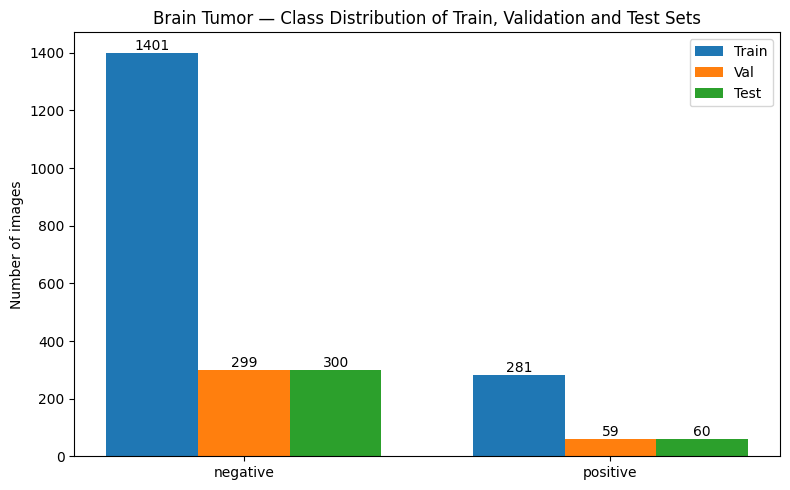

In [ ]:
labels_ = list(CFG.CLASS_TO_IDX)
counts = {s.capitalize(): [len(REAL_SPLIT[c][s]) for c in labels_] for s in ["train", "val", "test"]}
x = np.arange(len(labels_))
plt.figure(figsize=(8, 5))
for i, (name, vals) in enumerate(counts.items()):
    bars = plt.bar(x + (i - 1) * 0.25, vals, 0.25, label=name)
    for b in bars:
        plt.text(b.get_x() + b.get_width() / 2, b.get_height(), int(b.get_height()), ha="center", va="bottom")
plt.xticks(x, labels_)
plt.ylabel("Number of images")
plt.title("Brain Tumor — Class Distribution of Train, Validation and Test Sets")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(CFG.DRIVE_RESULTS_DIR, "class_distribution.png"), dpi=120, bbox_inches="tight")
plt.show()

## Bước 3 — StyleGAN2-ADA có điều kiện (bản chính thức NVlabs)

**3a.** Đóng gói **toàn bộ ảnh train của cả hai lớp** (không gồm val/test) thành file zip đúng định dạng
StyleGAN2-ADA: ảnh PNG 256×256 + `dataset.json` chứa nhãn lớp.

GAN học điều kiện theo nhãn, nên lớp đa số dạy cho mô hình các đặc trưng chung (giải phẫu não, độ tương phản MRI,
nền đen), còn nhãn chỉ điều khiển phần khác biệt. Đây là lý do không train GAN riêng trên lớp thiểu số.

In [ ]:
def build_stylegan_dataset_zip(cfg, split):
    labels = []
    with zipfile.ZipFile(cfg.LOCAL_GAN_DATASET, "w", compression=zipfile.ZIP_STORED) as zf:
        for label, idx in cfg.CLASS_TO_IDX.items():
            for f in split[label]["train"]:
                arcname = f"{label}/{f}"
                zf.write(os.path.join(cfg.LOCAL_PP, label, f), arcname=arcname)
                labels.append([arcname, idx])
        zf.writestr("dataset.json", json.dumps({"labels": labels}))
    n_per_class = {c: sum(1 for _, l in labels if l == i) for c, i in cfg.CLASS_TO_IDX.items()}
    print(f"Đã tạo {cfg.LOCAL_GAN_DATASET}: {len(labels)} ảnh {n_per_class}")


build_stylegan_dataset_zip(CFG, REAL_SPLIT)

# Kiểm tra dataset + cấu hình bằng --dry-run (không train)
sh(f"{sys.executable} train.py --outdir={CFG.LOCAL_GAN_RUNS}/dryrun --data={CFG.LOCAL_GAN_DATASET} "
   f"--gpus=1 --cond=1 --mirror={int(CFG.GAN_MIRROR)} --cfg={CFG.GAN_CFG} --batch={CFG.GAN_BATCH} "
   f"--gamma={CFG.GAN_GAMMA} --kimg=10 --metrics=none --dry-run", cwd=CFG.SG2_REPO)

Đã tạo /content/local_data_bt/gan_dataset/brain_tumor_train_cond_256.zip: 1682 ảnh {'negative': 1401, 'positive': 281}
$ /usr/bin/python3 train.py --outdir=/content/local_data_bt/gan_runs/dryrun --data=/content/local_data_bt/gan_dataset/brain_tumor_train_cond_256.zip --gpus=1 --cond=1 --mirror=1 --cfg=paper256 --batch=16 --gamma=1.0 --kimg=10 --metrics=none --dry-run

Training options:
{
  "num_gpus": 1,
  "image_snapshot_ticks": 50,
  "network_snapshot_ticks": 50,
  "metrics": [],
  "random_seed": 0,
  "training_set_kwargs": {
    "class_name": "training.dataset.ImageFolderDataset",
    "path": "/content/local_data_bt/gan_dataset/brain_tumor_train_cond_256.zip",
    "use_labels": true,
    "max_size": 1682,
    "xflip": true,
    "resolution": 256
  },
  "data_loader_kwargs": {
    "pin_memory": true,
    "num_workers": 3,
    "prefetch_factor": 2
  },
  "G_kwargs": {
    "class_name": "training.networks.Generator",
    "z_dim": 512,
    "w_dim": 512,
    "mapping_kwargs": {
      "nu

CompletedProcess(args='/usr/bin/python3 train.py --outdir=/content/local_data_bt/gan_runs/dryrun --data=/content/local_data_bt/gan_dataset/brain_tumor_train_cond_256.zip --gpus=1 --cond=1 --mirror=1 --cfg=paper256 --batch=16 --gamma=1.0 --kimg=10 --metrics=none --dry-run', returncode=0, stdout='\nTraining options:\n{\n  "num_gpus": 1,\n  "image_snapshot_ticks": 50,\n  "network_snapshot_ticks": 50,\n  "metrics": [],\n  "random_seed": 0,\n  "training_set_kwargs": {\n    "class_name": "training.dataset.ImageFolderDataset",\n    "path": "/content/local_data_bt/gan_dataset/brain_tumor_train_cond_256.zip",\n    "use_labels": true,\n    "max_size": 1682,\n    "xflip": true,\n    "resolution": 256\n  },\n  "data_loader_kwargs": {\n    "pin_memory": true,\n    "num_workers": 3,\n    "prefetch_factor": 2\n  },\n  "G_kwargs": {\n    "class_name": "training.networks.Generator",\n    "z_dim": 512,\n    "w_dim": 512,\n    "mapping_kwargs": {\n      "num_layers": 8\n    },\n    "synthesis_kwargs": {\

**3b.** Công cụ đánh giá: KID tính bằng **Inception của chính StyleGAN2-ADA** (cùng detector tác giả dùng),
so ảnh lớp thiểu số sinh ra (điều kiện c = lớp thiểu số) với **toàn bộ ảnh thật của lớp thiểu số trong tập train**.

In [ ]:
if CFG.SG2_REPO not in sys.path:
    sys.path.insert(0, CFG.SG2_REPO)
import dnnlib
import legacy
from metrics import metric_utils

TORCH_DEVICE = torch.device("cuda")
INCEPTION_URL = "https://nvlabs-fi-cdn.nvidia.com/stylegan2-ada-pytorch/pretrained/metrics/inception-2015-12-05.pt"


def get_inception():
    return metric_utils.get_feature_detector(INCEPTION_URL, device=TORCH_DEVICE)


@torch.no_grad()
def inception_features(images_uint8_nhwc, batch=64):
    det = get_inception()
    feats = []
    for s in range(0, len(images_uint8_nhwc), batch):
        x = torch.from_numpy(images_uint8_nhwc[s:s + batch]).permute(0, 3, 1, 2).to(TORCH_DEVICE)
        feats.append(det(x, return_features=True).cpu().numpy().astype(np.float64))
    return np.concatenate(feats, axis=0)


def load_images_uint8(paths):
    return np.stack([np.array(Image.open(p).convert("RGB")) for p in paths]).astype(np.uint8)


def kid_from_features(real, fake, num_subsets=50, max_subset_size=1000, seed=0):
    """Giống hệt metrics/kernel_inception_distance.py của StyleGAN2-ADA (có seed để lặp lại được)."""
    rng = np.random.default_rng(seed)
    n = real.shape[1]
    m = min(real.shape[0], fake.shape[0], max_subset_size)
    t = 0.0
    for _ in range(num_subsets):
        x = fake[rng.choice(fake.shape[0], m, replace=False)]
        y = real[rng.choice(real.shape[0], m, replace=False)]
        a = (x @ x.T / n + 1) ** 3 + (y @ y.T / n + 1) ** 3
        b = (x @ y.T / n + 1) ** 3
        t += (a.sum() - np.diag(a).sum()) / (m - 1) - b.sum() * 2 / m
    return float(t / num_subsets / m)


def load_G(pkl_path):
    with open(pkl_path, "rb") as f:
        return legacy.load_network_pkl(f)["G_ema"].to(TORCH_DEVICE).eval().requires_grad_(False)


@torch.no_grad()
def generate_class_images(G, n, class_idx, psi=1.0, seed=0, batch=32):
    gen = torch.Generator(device=TORCH_DEVICE).manual_seed(int(seed))
    out = []
    for s in range(0, n, batch):
        b = min(batch, n - s)
        z = torch.randn([b, G.z_dim], generator=gen, device=TORCH_DEVICE)
        c = torch.zeros([b, G.c_dim], device=TORCH_DEVICE)
        c[:, class_idx] = 1
        img = G(z, c, truncation_psi=psi, noise_mode="const")
        out.append((img.permute(0, 2, 3, 1) * 127.5 + 128).clamp(0, 255).to(torch.uint8).cpu().numpy())
    return np.concatenate(out, axis=0)


REAL_MIN_TRAIN_PATHS = [os.path.join(CFG.LOCAL_PP, MINORITY_CLASS, f) for f in REAL_SPLIT[MINORITY_CLASS]["train"]]
REAL_MIN_INCEPTION = inception_features(load_images_uint8(REAL_MIN_TRAIN_PATHS))
print("Inception features minority thật (train):", REAL_MIN_INCEPTION.shape)

Inception features minority thật (train): (281, 2048)


**3c.** Train StyleGAN2-ADA với **early stopping theo KID minority**:

- `train.py` chính thức chạy trong tiến trình con; mỗi `GAN_KIMG_PER_SNAP` kimg tác giả lưu một snapshot.
- Notebook đánh giá KID từng snapshot. Snapshot tốt nhất được copy lên Drive (`best.pkl`), snapshot mới nhất lưu `latest.pkl` để resume.
- Sau `GAN_MIN_KIMG`, nếu KID không giảm ≥ `GAN_MIN_REL_DELTA` trong `GAN_PATIENCE` snapshot liên tiếp → **dừng train**. Generator dùng ở các bước sau là **snapshot tốt nhất**, không phải snapshot cuối.
- Nếu Colab ngắt: chạy lại cell (không đặt `fresh_start=True`) → tự resume từ `latest.pkl`, giữ nguyên lịch sử KID và bộ đếm patience.

Quy đổi: 1 kimg = 1.000 ảnh thật mà D nhìn thấy. Với N ảnh train, 1 kimg ≈ 1000/N epoch.

In [ ]:
GAN_STATE_PATH = os.path.join(CFG.DRIVE_GAN_DIR, "gan_state.json")
GAN_BEST_PKL = os.path.join(CFG.DRIVE_GAN_DIR, "best.pkl")
GAN_LATEST_PKL = os.path.join(CFG.DRIVE_GAN_DIR, "latest.pkl")


def _default_state():
    return {"cum_kimg": 0, "history": [], "best_kid": None, "best_cum_kimg": None,
            "bad_count": 0, "finished": False, "stop_reason": None}


def _load_state():
    if os.path.exists(GAN_STATE_PATH):
        with open(GAN_STATE_PATH) as f:
            return json.load(f)
    return _default_state()


def _save_state(state):
    tmp = GAN_STATE_PATH + ".tmp"
    with open(tmp, "w") as f:
        json.dump(state, f, indent=2)
    os.replace(tmp, GAN_STATE_PATH)


def _list_run_dirs(outdir):
    return sorted(d for d in glob.glob(os.path.join(outdir, "0*")) if os.path.isdir(d))


def _list_snapshots(run_dir):
    snaps = []
    for p in glob.glob(os.path.join(run_dir, "network-snapshot-*.pkl")):
        snaps.append((int(os.path.basename(p).split("-")[-1].split(".")[0]), p))
    return sorted(snaps)


def _is_file_complete(path, wait=10):
    try:
        s1 = os.path.getsize(path)
        time.sleep(wait)
        s2 = os.path.getsize(path)
    except OSError:
        return False
    return s1 > 0 and s1 == s2


def _last_tick_line(log_path):
    try:
        with open(log_path) as f:
            ticks = [l.strip() for l in f if l.startswith("tick")]
        return ticks[-1] if ticks else "(chưa có tick)"
    except OSError:
        return "(chưa có log)"


def backup_logs_and_samples(run_dir, log_path):
    """Lưu log train + lưới ảnh mẫu (fakes*.png) của StyleGAN2-ADA lên Drive."""
    dst = os.path.join(CFG.DRIVE_GAN_DIR, "logs_and_samples")
    try:
        shutil.copy2(log_path, os.path.join(dst, os.path.basename(log_path)))
        if run_dir:
            for p in glob.glob(os.path.join(run_dir, "*.png")) + glob.glob(os.path.join(run_dir, "*.jsonl")):
                tag = os.path.basename(run_dir).split("-")[0]
                shutil.copy2(p, os.path.join(dst, f"run{tag}_{os.path.basename(p)}"))
    except OSError as e:
        print("  (không sao lưu được log/ảnh mẫu:", e, ")")


def evaluate_snapshot_kid(pkl_path):
    G = load_G(pkl_path)
    fake = generate_class_images(G, CFG.KID_N_GEN, CFG.MINORITY_IDX, psi=1.0, seed=CFG.KID_SEED)
    del G
    torch.cuda.empty_cache()
    return kid_from_features(REAL_MIN_INCEPTION, inception_features(fake),
                             num_subsets=CFG.KID_SUBSETS, seed=CFG.KID_SEED)


def train_stylegan2_ada_early_stopping(cfg, fresh_start=False):
    if fresh_start:
        for p in [GAN_STATE_PATH, GAN_BEST_PKL, GAN_LATEST_PKL]:
            if os.path.exists(p):
                os.remove(p)
        shutil.rmtree(cfg.LOCAL_GAN_RUNS, ignore_errors=True)
        print("fresh_start=True -> xóa trạng thái cũ, train từ đầu.")
    os.makedirs(cfg.LOCAL_GAN_RUNS, exist_ok=True)

    state = _load_state()
    if state["finished"]:
        print(f"GAN đã train xong ({state['stop_reason']}). Best KID = {state['best_kid']:.5f} "
              f"tại {state['best_cum_kimg']} kimg.")
        return GAN_BEST_PKL, state

    snap_ticks = max(1, cfg.GAN_KIMG_PER_SNAP // 4)   # 1 tick = 4 kimg (mặc định của tác giả)

    while not state["finished"]:
        offset = state["cum_kimg"]
        remaining = cfg.GAN_MAX_KIMG - offset
        if remaining < cfg.GAN_KIMG_PER_SNAP:
            state.update(finished=True, stop_reason=f"đạt GAN_MAX_KIMG={cfg.GAN_MAX_KIMG}")
            _save_state(state)
            break

        resume = None
        if offset > 0:
            if not os.path.exists(GAN_LATEST_PKL):
                raise RuntimeError("Có lịch sử train nhưng thiếu latest.pkl trên Drive -> chạy lại với fresh_start=True.")
            resume = GAN_LATEST_PKL
            print(f"Resume từ {resume} (đã train {offset} kimg)")

        cmd = [sys.executable, "train.py",
               f"--outdir={cfg.LOCAL_GAN_RUNS}", f"--data={cfg.LOCAL_GAN_DATASET}",
               "--gpus=1", "--cond=1", f"--mirror={int(cfg.GAN_MIRROR)}",
               f"--cfg={cfg.GAN_CFG}", f"--batch={cfg.GAN_BATCH}", f"--gamma={cfg.GAN_GAMMA}",
               f"--kimg={remaining}", f"--snap={snap_ticks}", "--metrics=none",
               "--aug=ada", f"--target={cfg.GAN_AUG_TARGET}", f"--seed={SEED}", "--workers=2"]
        if resume:
            cmd.append(f"--resume={resume}")
        print("Lệnh:", " ".join(cmd))

        existing_runs = set(_list_run_dirs(cfg.LOCAL_GAN_RUNS))
        log_path = os.path.join(cfg.LOCAL_GAN_RUNS, f"train_log_from_{offset}kimg.txt")
        log_f = open(log_path, "w")
        proc = subprocess.Popen(cmd, cwd=cfg.SG2_REPO, stdout=log_f, stderr=subprocess.STDOUT)

        run_dir = None
        evaluated = set()
        early_stopped = False

        def process_new_snapshots():
            nonlocal early_stopped
            if run_dir is None:
                return
            for kimg, pkl in _list_snapshots(run_dir):
                if pkl in evaluated:
                    continue
                if kimg == 0:                      # snapshot khởi tạo / mạng vừa resume -> bỏ qua
                    evaluated.add(pkl)
                    continue
                if not _is_file_complete(pkl):
                    return
                evaluated.add(pkl)
                cum = offset + kimg
                kid = evaluate_snapshot_kid(pkl)
                improved = state["best_kid"] is None or kid < state["best_kid"] * (1 - cfg.GAN_MIN_REL_DELTA)
                if improved:
                    shutil.copy2(pkl, GAN_BEST_PKL)
                    state.update(best_kid=kid, best_cum_kimg=cum, bad_count=0)
                elif cum >= cfg.GAN_MIN_KIMG:
                    state["bad_count"] += 1
                shutil.copy2(pkl, GAN_LATEST_PKL)
                state["cum_kimg"] = cum
                state["history"].append({"cum_kimg": cum, "kid": kid, "improved": bool(improved)})
                _save_state(state)
                os.remove(pkl)                      # đã lưu best/latest trên Drive, xóa bản cục bộ cho nhẹ đĩa
                backup_logs_and_samples(run_dir, log_path)
                print(f"[snapshot] {cum:5d} kimg | KID minority = {kid * 1e3:7.3f}e-3 | "
                      f"best = {state['best_kid'] * 1e3:7.3f}e-3 @ {state['best_cum_kimg']} kimg | "
                      f"patience {state['bad_count']}/{cfg.GAN_PATIENCE}{'  <-- tốt nhất' if improved else ''}")
                print("           ", _last_tick_line(log_path))
                if state["bad_count"] >= cfg.GAN_PATIENCE:
                    early_stopped = True
                    state.update(finished=True,
                                 stop_reason=f"early stopping tại {cum} kimg (best {state['best_cum_kimg']} kimg)")
                    _save_state(state)
                    return

        ret = None
        last_print = time.time()
        try:
            while True:
                ret = proc.poll()
                if run_dir is None:
                    new_runs = [d for d in _list_run_dirs(cfg.LOCAL_GAN_RUNS) if d not in existing_runs]
                    if new_runs:
                        run_dir = new_runs[0]
                        print("Thư mục run:", run_dir)
                process_new_snapshots()
                if early_stopped or ret is not None:
                    break
                if time.time() - last_print > 600:
                    print("  ...", _last_tick_line(log_path))
                    last_print = time.time()
                time.sleep(30)
        finally:
            if proc.poll() is None:
                proc.terminate()
                try:
                    proc.wait(timeout=60)
                except subprocess.TimeoutExpired:
                    proc.kill()
            log_f.close()
            backup_logs_and_samples(run_dir, log_path)

        if early_stopped:
            print(f"\nDỪNG SỚM: {state['stop_reason']}")
            break
        process_new_snapshots()                    # snapshot cuối (lưu khi train.py kết thúc)
        if early_stopped:
            print(f"\nDỪNG SỚM: {state['stop_reason']}")
            break
        if ret != 0:
            with open(log_path) as f:
                print("".join(f.readlines()[-60:]))
            raise RuntimeError(f"train.py lỗi (mã {ret}). Xem log: {log_path}")

    print(f"\nKết thúc. Best KID = {state['best_kid']:.5f} tại {state['best_cum_kimg']} kimg -> {GAN_BEST_PKL}")
    return GAN_BEST_PKL, state


# fresh_start=False: lần đầu tự train từ đầu (chưa có trạng thái); sau khi Colab ngắt thì tự RESUME.
# Chỉ đặt fresh_start=True khi muốn XÓA toàn bộ GAN cũ (ví dụ sau khi đổi GAN_GAMMA / GAN_CFG).
best_gan_pkl, gan_state = train_stylegan2_ada_early_stopping(CFG, fresh_start=False)

Lệnh: /usr/bin/python3 train.py --outdir=/content/local_data_bt/gan_runs --data=/content/local_data_bt/gan_dataset/brain_tumor_train_cond_256.zip --gpus=1 --cond=1 --mirror=1 --cfg=paper256 --batch=16 --gamma=1.0 --kimg=3000 --snap=25 --metrics=none --aug=ada --target=0.6 --seed=2026 --workers=2
Thư mục run: /content/local_data_bt/gan_runs/00000-brain_tumor_train_cond_256-cond-mirror-paper256-gamma1-kimg3000-batch16-ada-target0.6
  ... tick 7     kimg 28.0     time 9m 18s       sec/tick 62.8    sec/kimg 15.71   maintenance 0.0    cpumem 3.37   gpumem 4.80   augment 0.040
  ... tick 17    kimg 68.0     time 19m 45s      sec/tick 62.8    sec/kimg 15.69   maintenance 0.1    cpumem 3.37   gpumem 4.82   augment 0.036
Setting up PyTorch plugin "bias_act_plugin"... Done.
Setting up PyTorch plugin "upfirdn2d_plugin"... Done.
[snapshot]   100 kimg | KID minority = 385.954e-3 | best = 385.954e-3 @ 100 kimg | patience 0/5  <-- tốt nhất
            tick 25    kimg 100.0    time 28m 08s      sec/ti

**3d.** Nạp generator tốt nhất, xem đường KID và ảnh mẫu của từng lớp.

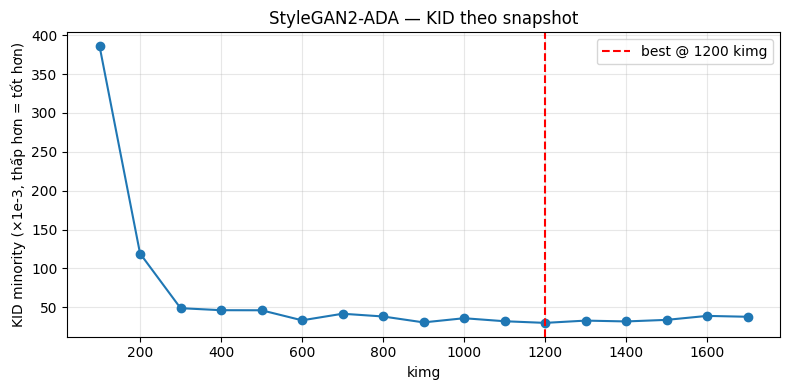

Trạng thái: early stopping tại 1700 kimg (best 1200 kimg)


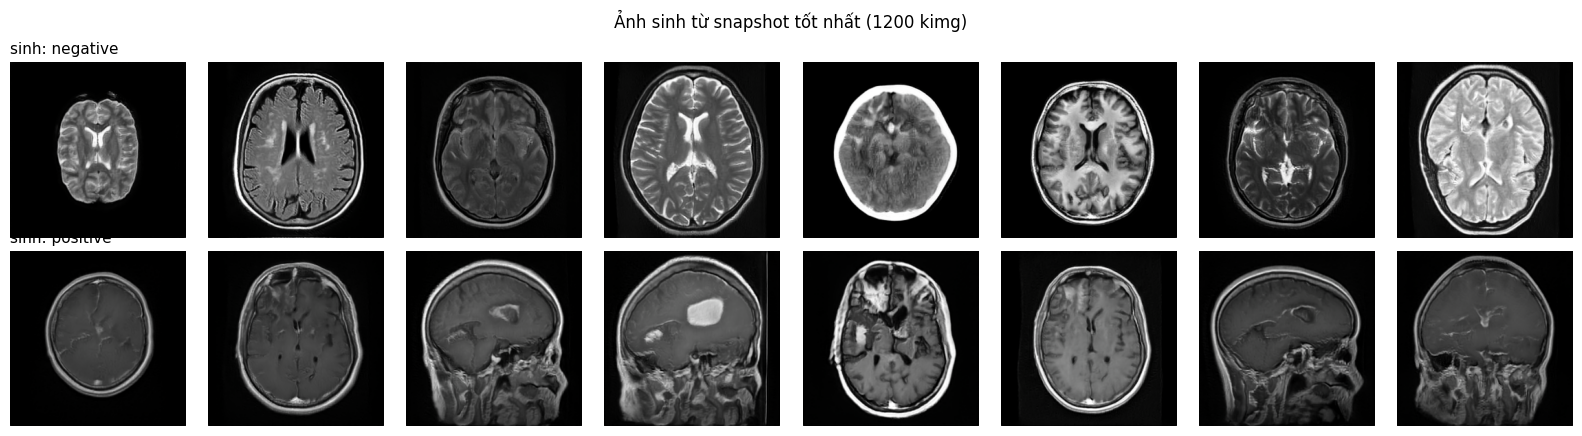

In [ ]:
gan_state = _load_state()
hist = pd.DataFrame(gan_state["history"])
if len(hist):
    plt.figure(figsize=(8, 4))
    plt.plot(hist["cum_kimg"], hist["kid"] * 1e3, marker="o")
    plt.axvline(gan_state["best_cum_kimg"], color="red", ls="--", label=f"best @ {gan_state['best_cum_kimg']} kimg")
    plt.xlabel("kimg")
    plt.ylabel("KID minority (×1e-3, thấp hơn = tốt hơn)")
    plt.title("StyleGAN2-ADA — KID theo snapshot")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
print("Trạng thái:", gan_state["stop_reason"])

G_best = load_G(GAN_BEST_PKL)
fig, axes = plt.subplots(2, 8, figsize=(16, 4.4))
for row, (label, idx) in enumerate(CFG.CLASS_TO_IDX.items()):
    imgs = generate_class_images(G_best, 8, idx, psi=CFG.TRUNC_PSI, seed=1)
    for col in range(8):
        axes[row, col].imshow(imgs[col])
        axes[row, col].axis("off")
    axes[row, 0].set_title(f"sinh: {label}", loc="left", fontsize=11)
plt.suptitle(f"Ảnh sinh từ snapshot tốt nhất ({gan_state['best_cum_kimg']} kimg)")
plt.tight_layout()
plt.show()

## Bước 4 — Sinh ảnh ứng viên

- **Pool lớp thiểu số:** sinh `k_max × N_SELECT` ảnh với điều kiện c = lớp thiểu số. Pool của các k nhỏ hơn là
  phần đầu của cùng pool (pool lồng nhau) để so sánh giữa các k công bằng.
- **Pool lớp đa số:** chỉ sinh khi `INCLUDE_M7 = True`, dùng cho biến thể M7 (ảnh sinh ở cả hai lớp).
- Pool được nén lên Drive; các phiên sau **giải nén lại đúng pool đó**, không sinh lại, để mọi lần chạy
  classifier đều dùng cùng một bộ ảnh.

In [ ]:
def generate_pool(G, cfg, n_images, class_idx, pool_name, seed):
    pool_dir = os.path.join(cfg.LOCAL_CANDIDATES, pool_name)
    shutil.rmtree(pool_dir, ignore_errors=True)
    os.makedirs(pool_dir)
    imgs = generate_class_images(G, n_images, class_idx, psi=cfg.TRUNC_PSI, seed=seed)
    paths = []
    for i, img in enumerate(tqdm(imgs, desc=f"Lưu {pool_name}")):
        p = os.path.join(pool_dir, f"synth_{i:05d}.png")
        Image.fromarray(img).save(p, format="PNG")
        paths.append(p)
    return paths


def get_or_restore_pool(G, cfg, n_images, class_idx, pool_name, seed, tag):
    zip_path = os.path.join(cfg.DRIVE_DATA_DIR, f"{pool_name}_{tag}.zip")
    pool_dir = os.path.join(cfg.LOCAL_CANDIDATES, pool_name)
    if os.path.exists(zip_path):
        shutil.rmtree(pool_dir, ignore_errors=True)
        shutil.unpack_archive(zip_path, pool_dir)
        paths = sorted(glob.glob(os.path.join(pool_dir, "synth_*.png")))
        print(f"Khôi phục {len(paths)} ảnh từ {zip_path}")
    else:
        paths = generate_pool(G, cfg, n_images, class_idx, pool_name, seed)
        shutil.make_archive(zip_path[:-4], "zip", pool_dir)
        print(f"Đã sinh {len(paths)} ảnh và lưu {zip_path}")
    return paths


TAG = f"from{gan_state['best_cum_kimg']}kimg"
n_max = int(np.ceil(max(CFG.K_VALUES) * N_SELECT))
minority_pool = get_or_restore_pool(G_best, CFG, n_max, CFG.MINORITY_IDX, "pool_minority", CFG.GEN_SEED, TAG)
candidate_paths_by_k = {k: minority_pool[:int(np.ceil(k * N_SELECT))] for k in CFG.K_VALUES}
for k, v in candidate_paths_by_k.items():
    print(f"  k={k}: pool {len(v)} ảnh")

majority_synth_paths = []
if CFG.INCLUDE_M7:
    majority_synth_paths = get_or_restore_pool(G_best, CFG, N_SELECT, CFG.MAJORITY_IDX,
                                               "pool_majority", CFG.GEN_SEED + 1, TAG)

# Giải phóng GPU cho TensorFlow ở các bước sau
del G_best
metric_utils._feature_detector_cache.clear()
gc.collect()
torch.cuda.empty_cache()

Lưu pool_minority:   0%|          | 0/3360 [00:00<?, ?it/s]

Đã sinh 3360 ảnh và lưu /content/drive/MyDrive/Colab Notebooks/ColabData/BrainTumor_GAN/checkpoints_bt/data/pool_minority_from1200kimg.zip
  k=1.0: pool 1120 ảnh
  k=1.5: pool 1680 ảnh
  k=2.0: pool 2240 ảnh
  k=3.0: pool 3360 ảnh


Lưu pool_majority:   0%|          | 0/1120 [00:00<?, ?it/s]

Đã sinh 1120 ảnh và lưu /content/drive/MyDrive/Colab Notebooks/ColabData/BrainTumor_GAN/checkpoints_bt/data/pool_majority_from1200kimg.zip


## Bước 4b — Phân tích fingerprint miền tần số (Frank et al., ICML 2020 — **dùng code gốc**)

Notebook **clone repo chính thức của nhóm tác giả**: `RUB-SysSec/GANDCTAnalysis` (giấy phép MIT), rồi gọi trực tiếp
các hàm của họ thay vì viết lại:

| Hàm dùng từ repo gốc | Vai trò |
|---|---|
| `src.image_np.load_image`, `src.image_np.dct2` | Nạp ảnh và tính DCT-II 2 chiều (chuẩn hoá trực giao) |
| `src.math.log_scale` | Chuyển sang thang log của trị tuyệt đối hệ số DCT |
| `src.math.welford` | Tính mean/var từng hệ số để chuẩn hoá zero-mean, unit-variance |
| `src.models.build_simple_cnn` | CNN nông 4 lớp — bộ phát hiện chính trong bài báo |
| `src.models.build_multinomial_regression` | Hồi quy đa thức — baseline tuyến tính của họ |

Chuỗi xử lý giữ đúng thứ tự trong `prepare_dataset.py` của họ: `load_image → dct2 → log_scale → normalize`.

Vai trò trong pipeline này là **phân tích và phát hiện**: đo xem ảnh sinh có để lại fingerprint tần số đủ mạnh để
trở thành shortcut hay không. Đây không phải phương pháp cải thiện ảnh.

Kết quả gồm phổ log-DCT trung bình (thật / sinh / chênh lệch) và AUC của hai bộ phát hiện nói trên. Đây là
**số đo cơ sở** để so với Bước 4c.

Chênh lệch kênh màu — ảnh thật: 0.0 | ảnh sinh: 0.0


DCT thật [goc]:   0%|          | 0/281 [00:00<?, ?it/s]

DCT sinh [goc]:   0%|          | 0/400 [00:00<?, ?it/s]

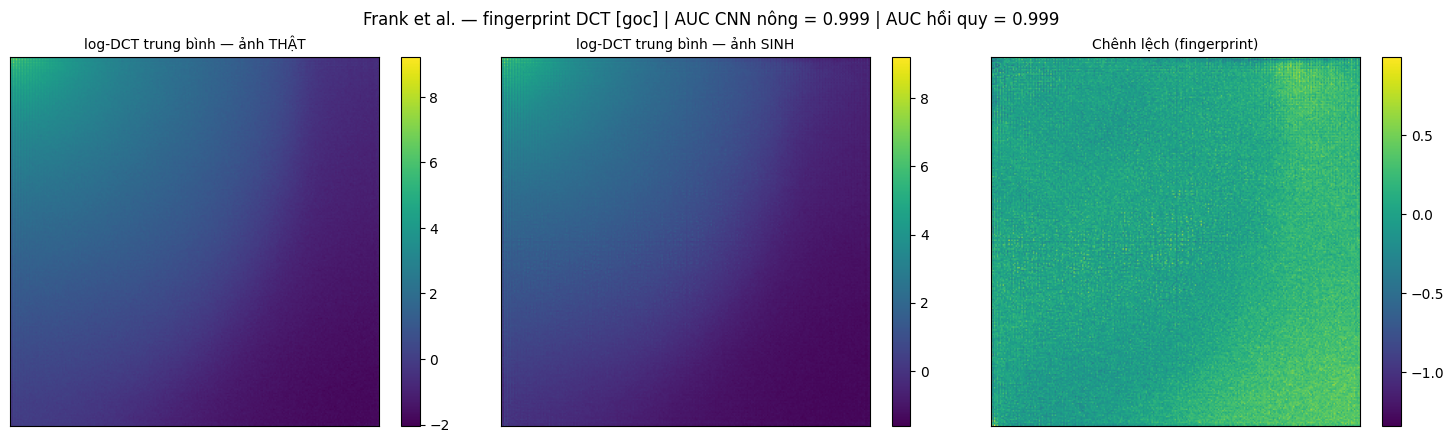

[goc] AUC CNN nông (Frank) = 0.9989 | AUC hồi quy (Frank) = 0.9987
[goc] AUC power profile (Dong) = 0.9831 | chênh lệch kênh màu ảnh sinh = 0.0000


In [ ]:
FRANK_REPO = "/content/GANDCTAnalysis"
if not os.path.isdir(FRANK_REPO):
    sh(f"git clone -q https://github.com/RUB-SysSec/GANDCTAnalysis.git {FRANK_REPO}")
if FRANK_REPO not in sys.path:
    sys.path.insert(0, FRANK_REPO)

# [PATCH] Keras 3 bắt buộc truyền pool_size cho AveragePooling2D (Keras 2 mặc định (2,2))
_models_py = "/content/GANDCTAnalysis/src/models.py"
_src = open(_models_py).read()
if "layers.AveragePooling2D()" in _src:
    open(_models_py, "w").write(_src.replace("layers.AveragePooling2D()", "layers.AveragePooling2D(pool_size=(2, 2))"))
    print("đã vá")

# --- Code gốc của Frank et al. (ICML 2020): repo RUB-SysSec/GANDCTAnalysis, giấy phép MIT ---
from src.image_np import dct2 as frank_dct2, load_image as frank_load_image
from src.math import log_scale as frank_log_scale, welford as frank_welford
from src.models import build_simple_cnn as frank_build_simple_cnn
from src.models import build_multinomial_regression as frank_build_regression

from sklearn.metrics import roc_auc_score

FREQ_FIG_DIR = os.path.join(CFG.DRIVE_RESULTS_DIR, "frequency_analysis")
os.makedirs(FREQ_FIG_DIR, exist_ok=True)


def frank_dct_log(path):
    """Đúng chuỗi xử lý của prepare_dataset.py: load_image -> dct2 -> log_scale."""
    return frank_log_scale(frank_dct2(frank_load_image(path, grayscale=True))).astype(np.float32)


def frank_features(paths, desc):
    return np.stack([frank_dct_log(p) for p in tqdm(paths, desc=desc)])


def frank_frequency_detector(real_paths, fake_paths, tag, n_max=400, epochs=15, seed=SEED):
    """Bộ phát hiện miền tần số của Frank et al.: DCT log-scaled + chuẩn hoá welford + CNN nông / hồi quy."""
    rng = np.random.default_rng(seed)
    rp = list(rng.choice(real_paths, min(n_max, len(real_paths)), replace=False))
    fp = list(rng.choice(fake_paths, min(n_max, len(fake_paths)), replace=False))

    X_real = frank_features(rp, f"DCT thật [{tag}]")
    X_fake = frank_features(fp, f"DCT sinh [{tag}]")
    X = np.concatenate([X_real, X_fake])
    y = np.r_[np.zeros(len(X_real)), np.ones(len(X_fake))].astype(np.float32)

    idx = rng.permutation(len(X))
    n_tr = int(0.8 * len(X))
    tr, te = idx[:n_tr], idx[n_tr:]

    mean, var = frank_welford(X[tr])                    # thống kê chỉ lấy từ phần train
    std = np.sqrt(var) + 1e-12
    Xn = ((X - mean) / std)[..., None].astype(np.float32)

    aucs = {}
    for name, builder in [("cnn_nong", lambda: frank_build_simple_cnn(Xn.shape[1:], 1)),
                          ("hoi_quy", lambda: frank_build_regression(Xn.shape[1:], 1))]:
        tf.keras.utils.set_random_seed(seed)
        model = builder()
        model.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss="binary_crossentropy",
                      metrics=[tf.keras.metrics.AUC(name="auc")])
        model.fit(Xn[tr], y[tr], validation_data=(Xn[te], y[te]), epochs=epochs, batch_size=32, verbose=0)
        aucs[name] = float(roc_auc_score(y[te], model.predict(Xn[te], verbose=0).ravel()))
        del model
        tf.keras.backend.clear_session()

    mean_real, mean_fake = X_real.mean(axis=0), X_fake.mean(axis=0)
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
    for ax, (m, t) in zip(axes, [(mean_real, "log-DCT trung bình — ảnh THẬT"),
                                 (mean_fake, "log-DCT trung bình — ảnh SINH"),
                                 (mean_fake - mean_real, "Chênh lệch (fingerprint)")]):
        im = ax.imshow(m, cmap="viridis")
        ax.set_title(t, fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])
        fig.colorbar(im, ax=ax, fraction=0.046)
    fig.suptitle(f"Frank et al. — fingerprint DCT [{tag}] | AUC CNN nông = {aucs['cnn_nong']:.3f} | "
                 f"AUC hồi quy = {aucs['hoi_quy']:.3f}", fontsize=12)
    fig.tight_layout()
    fig.savefig(os.path.join(FREQ_FIG_DIR, f"frank_dct_{tag}.png"), dpi=120, bbox_inches="tight")
    plt.show()

    print(f"[{tag}] AUC CNN nông (Frank) = {aucs['cnn_nong']:.4f} | AUC hồi quy (Frank) = {aucs['hoi_quy']:.4f}")
    return {"tag": tag, "auc_frank_cnn": aucs["cnn_nong"], "auc_frank_regression": aucs["hoi_quy"]}


def radial_power_profile(magnitude):
    """Algorithm 1 (Dong et al.): cộng biên độ theo bán kính rồi chuẩn hoá theo thành phần DC."""
    M = magnitude.shape[0]
    yy, xx = np.mgrid[0:M, 0:M]
    idx = np.floor(np.sqrt((yy - 0.5 * M) ** 2 + (xx - 0.5 * M) ** 2)).astype(int)
    prof = np.bincount(idx.ravel(), weights=magnitude.ravel(), minlength=int(np.floor(np.sqrt(2) * M)))
    return prof / (prof[0] + 1e-12)


def power_profile_auc(real_paths, fake_paths, n_max=400, seed=SEED):
    """Bộ phát hiện dựa trên profile công suất — đây mới là thứ PDC của Dong et al. nhắm tới."""
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import StratifiedKFold, cross_val_predict
    from sklearn.pipeline import make_pipeline
    from sklearn.preprocessing import StandardScaler
    rng = np.random.default_rng(seed)
    rp = list(rng.choice(real_paths, min(n_max, len(real_paths)), replace=False))
    fp = list(rng.choice(fake_paths, min(n_max, len(fake_paths)), replace=False))
    prof = lambda ps: np.stack([radial_power_profile(np.abs(np.fft.fftshift(
        np.fft.fft2(np.asarray(Image.open(p).convert("L"), dtype=np.float64))))) for p in ps])
    X = np.concatenate([prof(rp), prof(fp)])
    y = np.r_[np.zeros(len(rp)), np.ones(len(fp))]
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, C=0.1, class_weight="balanced"))
    p = cross_val_predict(clf, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=seed),
                          method="predict_proba")[:, 1]
    return float(roc_auc_score(y, p))


def fingerprint_report(real_paths, fake_paths, tag, n_max=400):
    rep = frank_frequency_detector(real_paths, fake_paths, tag, n_max=n_max)
    rep["auc_power_profile"] = power_profile_auc(real_paths, fake_paths, n_max=n_max)
    rep["chenh_lech_kenh_mau_sinh"] = float(np.mean([channel_gap(p) for p in fake_paths[:100]]))
    print(f"[{tag}] AUC power profile (Dong) = {rep['auc_power_profile']:.4f} | "
          f"chênh lệch kênh màu ảnh sinh = {rep['chenh_lech_kenh_mau_sinh']:.4f}")
    return rep


def channel_gap(path):
    """Mức lệch giữa các kênh R,G,B. Ảnh xám thật cho đúng 0.0; ảnh GAN 3 kênh thì khác 0."""
    a = np.asarray(Image.open(path).convert("RGB"), dtype=np.float64)
    return float(np.abs(np.diff(a, axis=2)).mean())


real_min_train_paths = [os.path.join(CFG.LOCAL_PP, MINORITY_CLASS, f) for f in REAL_SPLIT[MINORITY_CLASS]["train"]]
print("Chênh lệch kênh màu — ảnh thật:", np.mean([channel_gap(p) for p in real_min_train_paths[:100]]),
      "| ảnh sinh:", np.mean([channel_gap(p) for p in minority_pool[:100]]))
freq_reports = [fingerprint_report(real_min_train_paths, minority_pool, "goc")]

In [ ]:
CFG.HARMONIZE_SYNTH_CHANNELS = "auto"
CFG.MATCH_RESIZE_CHAIN = False

Khôi phục 3360 ảnh đã chuẩn hoá từ /content/drive/MyDrive/Colab Notebooks/ColabData/BrainTumor_GAN/checkpoints_bt/data/pool_minority_harmonized_from1200kimg.zip
Khôi phục 1120 ảnh đã chuẩn hoá từ /content/drive/MyDrive/Colab Notebooks/ColabData/BrainTumor_GAN/checkpoints_bt/data/pool_majority_harmonized_from1200kimg.zip


DCT thật [sau_chuan_hoa]:   0%|          | 0/281 [00:00<?, ?it/s]

DCT sinh [sau_chuan_hoa]:   0%|          | 0/400 [00:00<?, ?it/s]

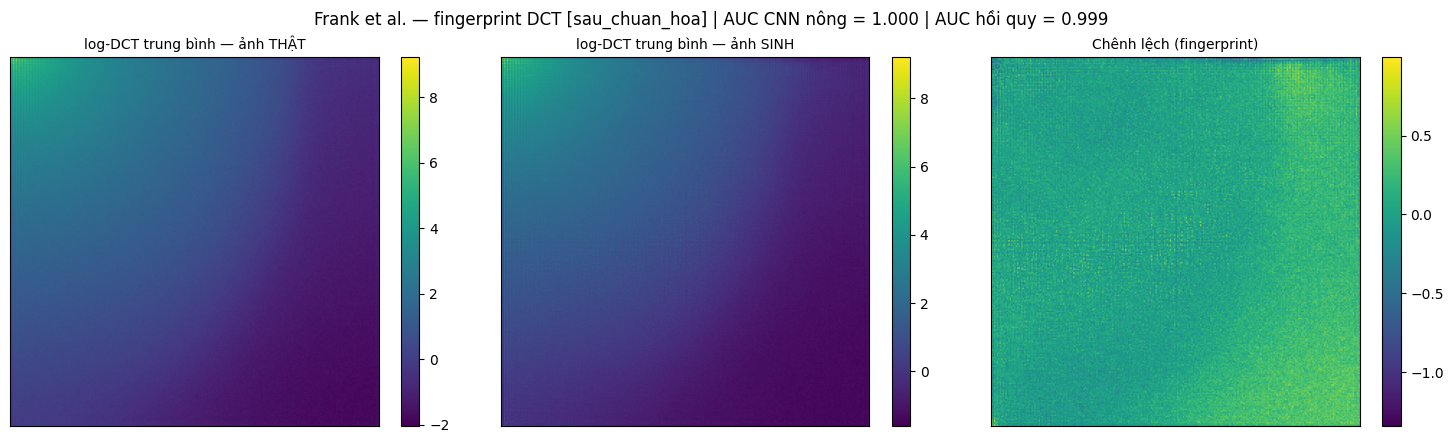

[sau_chuan_hoa] AUC CNN nông (Frank) = 0.9996 | AUC hồi quy (Frank) = 0.9987
[sau_chuan_hoa] AUC power profile (Dong) = 0.9831 | chênh lệch kênh màu ảnh sinh = 0.0000

=== Fingerprint trước và sau khi chuẩn hoá đặc tính kỹ thuật ===
          tag  auc_frank_cnn  auc_frank_regression  auc_power_profile  chenh_lech_kenh_mau_sinh
          goc         0.9989                0.9987             0.9831                       0.0
sau_chuan_hoa         0.9996                0.9987             0.9831                       0.0


In [ ]:
def harmonize_pool(paths, pool_name, cfg, tag):
    """Đưa ảnh sinh về cùng đặc tính kỹ thuật với ảnh thật: ảnh xám nhân bản 3 kênh (+ tuỳ chọn khớp chuỗi resize)."""
    zip_path = os.path.join(cfg.DRIVE_DATA_DIR, f"{pool_name}_harmonized_{tag}.zip")
    out_dir = os.path.join(cfg.LOCAL_CANDIDATES, f"{pool_name}_harmonized")
    if os.path.exists(zip_path):
        shutil.rmtree(out_dir, ignore_errors=True)
        shutil.unpack_archive(zip_path, out_dir)
        new_paths = sorted(glob.glob(os.path.join(out_dir, "*.png")))
        print(f"Khôi phục {len(new_paths)} ảnh đã chuẩn hoá từ {zip_path}")
        return new_paths

    shutil.rmtree(out_dir, ignore_errors=True)
    os.makedirs(out_dir)
    new_paths = []
    for p in tqdm(paths, desc=f"Chuẩn hoá {pool_name}"):
        img = Image.open(p).convert("RGB")
        if cfg.MATCH_RESIZE_CHAIN and RESIZE_REF_SIDE:
            img = img.resize((RESIZE_REF_SIDE, RESIZE_REF_SIDE), _BILINEAR).resize(
                (cfg.IMG_SIZE, cfg.IMG_SIZE), _BILINEAR)
        if cfg.HARMONIZE_SYNTH_CHANNELS:
            g = np.asarray(img.convert("L"))
            img = Image.fromarray(np.stack([g] * 3, axis=-1))
        q = os.path.join(out_dir, os.path.basename(p))
        img.save(q, format="PNG")
        new_paths.append(q)
    shutil.make_archive(zip_path[:-4], "zip", out_dir)
    print("Đã lưu", zip_path)
    return new_paths


# Ảnh thật có phải ảnh xám thuần không? (quyết định tự động khi HARMONIZE_SYNTH_CHANNELS = "auto")
real_gap = float(np.mean([channel_gap(p) for p in real_min_train_paths[:100]]))
if CFG.HARMONIZE_SYNTH_CHANNELS == "auto":
    CFG.HARMONIZE_SYNTH_CHANNELS = real_gap < 1e-6
    print(f"Chênh lệch kênh màu của ảnh thật = {real_gap:.6f} -> "
          f"HARMONIZE_SYNTH_CHANNELS = {CFG.HARMONIZE_SYNTH_CHANNELS}")

# Kích thước tham chiếu cho chuỗi resize (trung vị cạnh ngắn của ảnh GỐC trước tiền xử lý)
RESIZE_REF_SIDE = None
if CFG.MATCH_RESIZE_CHAIN:
    raw_files = sorted(glob.glob(os.path.join(CFG.LOCAL_RAW, MINORITY_CLASS, "*")))[:200]
    sides = [min(Image.open(p).size) for p in raw_files]
    RESIZE_REF_SIDE = int(np.median(sides))
    print(f"Trung vị cạnh ngắn của ảnh gốc = {RESIZE_REF_SIDE} -> ảnh sinh sẽ đi qua cùng chuỗi nội suy")

if CFG.HARMONIZE_SYNTH_CHANNELS or CFG.MATCH_RESIZE_CHAIN:
    minority_pool = harmonize_pool(minority_pool, "pool_minority", CFG, TAG)
    candidate_paths_by_k = {k: minority_pool[:int(np.ceil(k * N_SELECT))] for k in CFG.K_VALUES}
    if CFG.INCLUDE_M7 and majority_synth_paths:
        majority_synth_paths = harmonize_pool(majority_synth_paths, "pool_majority", CFG, TAG)
    freq_reports.append(fingerprint_report(real_min_train_paths, minority_pool, "sau_chuan_hoa"))
    print("\n=== Fingerprint trước và sau khi chuẩn hoá đặc tính kỹ thuật ===")
    print(pd.DataFrame(freq_reports).round(4).to_string(index=False))
else:
    print("Không cần chuẩn hoá: ảnh thật không phải ảnh xám thuần và MATCH_RESIZE_CHAIN = False.")

In [ ]:
import importlib, src.models
importlib.reload(src.models)
from src.models import build_simple_cnn as frank_build_simple_cnn
from src.models import build_multinomial_regression as frank_build_regression

## Bước 5 — Trích đặc trưng & tính CDS

EfficientNet-B0 (ImageNet) chỉ dùng để trích embedding cho CDS/Diversity, khác với 3 classifier ở Bước 9.

In [ ]:
_feature_extractor = tf.keras.applications.EfficientNetB0(
    include_top=False, weights="imagenet", pooling="avg",
    input_shape=(CFG.FEATURE_SIZE, CFG.FEATURE_SIZE, 3))
_feature_extractor.trainable = False


def embed_images(image_paths, batch_size=32):
    def _load(path):
        img = tf.io.decode_png(tf.io.read_file(path), channels=3)
        img = tf.image.resize(img, [CFG.FEATURE_SIZE, CFG.FEATURE_SIZE])
        return tf.keras.applications.efficientnet.preprocess_input(img)

    ds = (tf.data.Dataset.from_tensor_slices(list(image_paths))
          .map(_load, num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size).prefetch(tf.data.AUTOTUNE))
    return np.concatenate([_feature_extractor(b, training=False).numpy() for b in ds], axis=0)


def cosine_similarity_matrix(A, B):
    A = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-12)
    B = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-12)
    return A @ B.T


def compute_cds(candidate_emb, minority_emb, majority_emb, lambda_):
    S_same = cosine_similarity_matrix(candidate_emb, minority_emb).max(axis=1)
    S_other = cosine_similarity_matrix(candidate_emb, majority_emb).max(axis=1)
    return S_same - lambda_ * S_other, S_same, S_other


real_minority_paths = [os.path.join(CFG.LOCAL_PP, MINORITY_CLASS, f) for f in REAL_SPLIT[MINORITY_CLASS]["train"]]
real_majority_paths = [os.path.join(CFG.LOCAL_PP, MAJORITY_CLASS, f) for f in REAL_SPLIT[MAJORITY_CLASS]["train"]]
real_minority_emb = embed_images(real_minority_paths)
real_majority_emb = embed_images(real_majority_paths)
print("Embedding:", real_minority_emb.shape, real_majority_emb.shape)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Embedding: (281, 1280) (1401, 1280)


## Bước 6 — Diversity & Greedy DASS Selection

```
D(q) = 1 - max similarity(q, z), z thuộc tập đã chọn
Score(q) = CDS(q) + beta * D(q)
```

In [ ]:
def greedy_dass_selection(candidate_emb, cds_scores, n_select, beta):
    n_candidates = candidate_emb.shape[0]
    remaining = set(range(n_candidates))
    first_idx = int(np.argmax(cds_scores))
    selected = [first_idx]
    remaining.discard(first_idx)
    emb_norm = candidate_emb / (np.linalg.norm(candidate_emb, axis=1, keepdims=True) + 1e-12)
    max_sim_to_selected = emb_norm @ emb_norm[first_idx]
    while len(selected) < n_select and remaining:
        remaining_list = np.fromiter(remaining, dtype=int)
        score = cds_scores[remaining_list] + beta * (1.0 - max_sim_to_selected[remaining_list])
        best_idx = int(remaining_list[int(np.argmax(score))])
        selected.append(best_idx)
        remaining.discard(best_idx)
        max_sim_to_selected = np.maximum(max_sim_to_selected, emb_norm @ emb_norm[best_idx])
    return selected


def diversity_only_selection(candidate_emb, n_select):
    return greedy_dass_selection(candidate_emb, np.zeros(candidate_emb.shape[0]), n_select, beta=1.0)

## Bước 7 — Các biến thể lọc

| ID | Phương pháp |
|---|---|
| M0 | Real-only (không dùng ảnh sinh) — **baseline, mốc so sánh thống kê** |
| M1 | Unfiltered (N_SELECT ảnh đầu tiên do GAN sinh, không lọc) |
| M2 | Random (chọn ngẫu nhiên N_SELECT ảnh từ pool k) |
| M3 | S_same only |
| M4 | CDS only (S_same − λ·S_other) |
| M5 | Diversity only |
| M6 | **DASS** (CDS + Diversity — đề xuất) |
| M7 | **DASS + ảnh sinh ở cả hai lớp** (chống shortcut; kèm class weight) |

**Vì sao có M7.** Nếu ảnh sinh chỉ xuất hiện ở lớp thiểu số thì "trông giống ảnh GAN" trở thành manh mối
dự đoán nhãn, và classifier có thể học manh mối đó thay vì học bệnh (shortcut learning). M7 thêm N_SELECT ảnh
sinh vào **lớp đa số** nữa, nên dấu vết GAN không còn gắn với một nhãn cụ thể. Đánh đổi: lớp đa số to ra nên
mất cân bằng quay lại một phần, và được bù bằng class weight. Bước 7c đo trực tiếp mức rủi ro shortcut này.

In [ ]:
def run_filtering_methods(cfg, n_select, k):
    """Trả về {method_id: {"sel_idx", "selected", "removed", "emb", "class_weight", "synthetic_majority"}}."""
    pool = candidate_paths_by_k[k]
    pool_emb = embed_images(pool)
    cds_scores, S_same, S_other = compute_cds(pool_emb, real_minority_emb, real_majority_emb, cfg.CDS_LAMBDA)

    def pack(sel_idx, class_weight=False, synthetic_majority=()):
        sel_idx = [int(i) for i in sel_idx]
        s = set(sel_idx)
        return {"sel_idx": sel_idx,
                "selected": [pool[i] for i in sel_idx],
                "removed": [pool[i] for i in range(len(pool)) if i not in s],
                "emb": pool_emb[sel_idx] if sel_idx else None,
                "class_weight": class_weight,
                "synthetic_majority": list(synthetic_majority)}

    res = {}
    res["M0_real_only"] = pack([])
    # M1: pool lồng nhau -> N_SELECT ảnh đầu của pool chính là toàn bộ pool k=1.0
    res["M1_unfiltered"] = pack(range(n_select))
    rng = np.random.default_rng(SEED)
    res["M2_random"] = pack(rng.choice(len(pool), size=n_select, replace=False))
    res["M3_s_same_only"] = pack(np.argsort(-S_same)[:n_select])
    res["M4_cds_only"] = pack(np.argsort(-cds_scores)[:n_select])
    res["M5_diversity_only"] = pack(diversity_only_selection(pool_emb, n_select))
    res["M6_dass"] = pack(greedy_dass_selection(pool_emb, cds_scores, n_select, cfg.DASS_BETA))
    if cfg.INCLUDE_M7 and majority_synth_paths:
        res["M7_dass_both_classes"] = pack(res["M6_dass"]["sel_idx"], class_weight=True,
                                           synthetic_majority=majority_synth_paths)
    for name, v in res.items():
        print(f"  {name}: selected={len(v['selected'])}, removed={len(v['removed'])}, "
              f"synth_majority={len(v['synthetic_majority'])}, class_weight={v['class_weight']}")
    global POOL_INFO   # điểm số của toàn bộ pool, dùng cho phần hiển thị ở Bước 7b
    POOL_INFO = {"pool": pool, "emb": pool_emb, "cds": cds_scores, "S_same": S_same, "S_other": S_other, "k": k}
    return res


def plot_image_grid(image_paths, title, num_cols=8, max_images=16):
    n = min(len(image_paths), max_images)
    if n == 0:
        return
    num_rows = int(np.ceil(n / num_cols))
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 1.4, num_rows * 1.4))
    for i, ax in enumerate(np.array(axes).reshape(-1)):
        if i < n:
            ax.imshow(Image.open(image_paths[i]))
        ax.axis("off")
    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


filtering_results_k = run_filtering_methods(CFG, N_SELECT, CFG.K_RUN)
with open(os.path.join(CFG.DRIVE_DATA_DIR, f"selections_k{CFG.K_RUN}.json"), "w") as f:
    json.dump({m: [os.path.basename(p) for p in v["selected"]] for m, v in filtering_results_k.items()}, f, indent=1)
print("Đã lưu danh sách ảnh được chọn của từng phương pháp vào", CFG.DRIVE_DATA_DIR)

  M0_real_only: selected=0, removed=1680, synth_majority=0, class_weight=False
  M1_unfiltered: selected=1120, removed=560, synth_majority=0, class_weight=False
  M2_random: selected=1120, removed=560, synth_majority=0, class_weight=False
  M3_s_same_only: selected=1120, removed=560, synth_majority=0, class_weight=False
  M4_cds_only: selected=1120, removed=560, synth_majority=0, class_weight=False
  M5_diversity_only: selected=1120, removed=560, synth_majority=0, class_weight=False
  M6_dass: selected=1120, removed=560, synth_majority=0, class_weight=False
  M7_dass_both_classes: selected=1120, removed=560, synth_majority=1120, class_weight=True
Đã lưu danh sách ảnh được chọn của từng phương pháp vào /content/drive/MyDrive/Colab Notebooks/ColabData/BrainTumor_GAN/checkpoints_bt/data


## Bước 7b — Hiển thị ảnh được chọn và ảnh bị loại

1. **Bảng toàn bộ ứng viên** (lưu CSV lên Drive): tên file, S_same, S_other, CDS, thứ hạng CDS, và cột True/False cho từng phương pháp.
2. **Biểu đồ phân tán S_other – S_same** cho từng phương pháp: đỏ = được chọn, xám = bị loại.
   Góc **trên-trái** là ảnh giống minority thật và ít giống majority — vùng mong muốn. Đường chéo là S_same = S_other.
3. **Lưới ảnh** được chọn (viền xanh) / bị loại (viền đỏ), ghi điểm dưới mỗi ảnh. Có 3 chế độ:
   `random` (mẫu ngẫu nhiên), `extreme` (chọn tốt nhất vs loại tệ nhất theo CDS), `boundary` (ảnh sát ranh giới quyết định).
4. **Ảnh sinh đặt cạnh ảnh minority thật gần nhất**: nếu gần như trùng khớp → GAN đang "học thuộc".
5. **Mức trùng lặp (Jaccard)** giữa tập ảnh được chọn của các phương pháp.

Mọi hình được lưu vào `results_bt/selection_figures_k{K_RUN}/` trên Drive.

In [ ]:
FIG_DIR = os.path.join(CFG.DRIVE_RESULTS_DIR, f"selection_figures_k{CFG.K_RUN}")
os.makedirs(FIG_DIR, exist_ok=True)
SYNTH_METHODS = [m for m, v in filtering_results_k.items() if v["selected"]]


def _save(fig, name):
    fig.savefig(os.path.join(FIG_DIR, name), dpi=120, bbox_inches="tight")


# ---------- (1) Bảng toàn bộ ứng viên ----------
def build_selection_table():
    P = POOL_INFO
    df = pd.DataFrame({"file": [os.path.basename(p) for p in P["pool"]],
                       "S_same": P["S_same"], "S_other": P["S_other"], "CDS": P["cds"]})
    df["rank_CDS"] = df["CDS"].rank(ascending=False, method="first").astype(int)
    for m in SYNTH_METHODS:
        df[m] = False
        df.loc[filtering_results_k[m]["sel_idx"], m] = True
    df["so_phuong_phap_chon"] = df[SYNTH_METHODS].sum(axis=1)
    return df


selection_df = build_selection_table()
selection_df.to_csv(os.path.join(CFG.DRIVE_RESULTS_DIR, f"candidate_selection_table_k{CFG.K_RUN}.csv"), index=False)
print(f"Pool k={CFG.K_RUN}: {len(selection_df)} ứng viên | mỗi phương pháp chọn {N_SELECT}")
print(selection_df[SYNTH_METHODS].sum().rename("so_anh_duoc_chon").to_string())


# ---------- (2) Phân tán S_other - S_same ----------
def plot_selection_scatter():
    S_same, S_other = POOL_INFO["S_same"], POOL_INFO["S_other"]
    cols = 3
    rows = int(np.ceil(len(SYNTH_METHODS) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 4.4 * rows), sharex=True, sharey=True)
    axes = np.array(axes).reshape(-1)
    lo = min(S_same.min(), S_other.min()) - 0.01
    hi = max(S_same.max(), S_other.max()) + 0.01
    for ax, m in zip(axes, SYNTH_METHODS):
        sel = selection_df[m].values
        ax.scatter(S_other[~sel], S_same[~sel], s=7, c="lightgray", label=f"bị loại ({(~sel).sum()})")
        ax.scatter(S_other[sel], S_same[sel], s=7, c="tab:red", label=f"được chọn ({sel.sum()})")
        ax.plot([lo, hi], [lo, hi], "k--", lw=0.8)
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_title(m)
        ax.set_xlabel("S_other (giống majority thật)")
        ax.set_ylabel("S_same (giống minority thật)")
        ax.legend(fontsize=8, loc="lower right")
    for ax in axes[len(SYNTH_METHODS):]:
        ax.axis("off")
    fig.suptitle(f"Ảnh được chọn / bị loại trong không gian điểm (k={CFG.K_RUN})", fontsize=14)
    fig.tight_layout()
    _save(fig, "scatter_all_methods.png")
    plt.show()


# ---------- (3) Lưới ảnh được chọn / bị loại, có ghi điểm ----------
def show_selected_vs_removed(method, n=8, mode="random", seed=0):
    """mode: 'random' | 'extreme' (chọn CDS cao nhất vs loại CDS thấp nhất) | 'boundary' (chọn CDS thấp nhất vs loại CDS cao nhất)."""
    sel_mask = selection_df[method].values
    sel_idx, rem_idx = np.where(sel_mask)[0], np.where(~sel_mask)[0]
    cds = POOL_INFO["cds"]
    rng = np.random.default_rng(seed)
    if mode == "random":
        a = rng.choice(sel_idx, min(n, len(sel_idx)), replace=False)
        b = rng.choice(rem_idx, min(n, len(rem_idx)), replace=False)
    elif mode == "extreme":
        a = sel_idx[np.argsort(-cds[sel_idx])][:n]
        b = rem_idx[np.argsort(cds[rem_idx])][:n]
    elif mode == "boundary":
        a = sel_idx[np.argsort(cds[sel_idx])][:n]
        b = rem_idx[np.argsort(-cds[rem_idx])][:n]
    else:
        raise ValueError(mode)
    fig, axes = plt.subplots(2, n, figsize=(n * 1.75, 4.8))
    for row, (idxs, color, label) in enumerate([(a, "tab:green", "ĐƯỢC CHỌN"), (b, "tab:red", "BỊ LOẠI")]):
        for col in range(n):
            ax = axes[row, col]
            ax.set_xticks([])
            ax.set_yticks([])
            if col >= len(idxs):
                ax.axis("off")
                continue
            i = idxs[col]
            ax.imshow(Image.open(POOL_INFO["pool"][i]))
            for sp in ax.spines.values():
                sp.set_edgecolor(color)
                sp.set_linewidth(4)
            ax.set_xlabel(f"CDS {cds[i]:.3f}\nSs {POOL_INFO['S_same'][i]:.2f} | So {POOL_INFO['S_other'][i]:.2f}", fontsize=7)
        axes[row, 0].set_ylabel(label, fontsize=11, color=color, fontweight="bold")
    fig.suptitle(f"{method} (k={CFG.K_RUN}) — chế độ '{mode}'", fontsize=12)
    fig.tight_layout()
    _save(fig, f"grid_{method}_{mode}.png")
    plt.show()


# ---------- (4) Ảnh sinh cạnh ảnh minority thật gần nhất ----------
def show_nearest_real(method, n=6):
    idx = filtering_results_k[method]["sel_idx"][:n]
    sims = cosine_similarity_matrix(POOL_INFO["emb"][idx], real_minority_emb)
    nn = sims.argmax(axis=1)
    fig, axes = plt.subplots(2, n, figsize=(n * 1.9, 4.4))
    for col, (i, j) in enumerate(zip(idx, nn)):
        axes[0, col].imshow(Image.open(POOL_INFO["pool"][i]))
        axes[0, col].set_title(os.path.basename(POOL_INFO["pool"][i]), fontsize=7)
        axes[1, col].imshow(Image.open(real_minority_paths[j]))
        axes[1, col].set_title(f"cos = {sims[col, j]:.3f}", fontsize=8)
        axes[0, col].axis("off")
        axes[1, col].axis("off")
    axes[0, 0].text(-0.15, 0.5, "ẢNH SINH", transform=axes[0, 0].transAxes, rotation=90, va="center", ha="right")
    axes[1, 0].text(-0.15, 0.5, "THẬT GẦN NHẤT", transform=axes[1, 0].transAxes, rotation=90, va="center", ha="right")
    fig.suptitle(f"{method}: ảnh được chọn và ảnh minority thật gần nhất (kiểm tra học thuộc)", fontsize=11)
    fig.tight_layout()
    _save(fig, f"nearest_real_{method}.png")
    plt.show()


# ---------- (5) Mức trùng lặp giữa các phương pháp ----------
def plot_overlap():
    M = selection_df[SYNTH_METHODS].values.astype(bool)
    n = len(SYNTH_METHODS)
    J = np.zeros((n, n))
    for a in range(n):
        for b in range(n):
            J[a, b] = (M[:, a] & M[:, b]).sum() / max(1, (M[:, a] | M[:, b]).sum())
    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(J, vmin=0, vmax=1, cmap="Blues")
    ax.set_xticks(range(n), SYNTH_METHODS, rotation=45, ha="right")
    ax.set_yticks(range(n), SYNTH_METHODS)
    for a in range(n):
        for b in range(n):
            ax.text(b, a, f"{J[a, b]:.2f}", ha="center", va="center", color="white" if J[a, b] > 0.6 else "black", fontsize=8)
    fig.colorbar(im, ax=ax, label="Jaccard")
    ax.set_title(f"Mức trùng lặp tập ảnh được chọn (k={CFG.K_RUN})")
    fig.tight_layout()
    _save(fig, "overlap_jaccard.png")
    plt.show()


if CFG.SHOW_GRIDS:
    plot_selection_scatter()
    for m in SYNTH_METHODS:
        show_selected_vs_removed(m, mode="random")
    show_selected_vs_removed("M6_dass", mode="extreme")
    show_selected_vs_removed("M6_dass", mode="boundary")
    show_nearest_real("M6_dass")
    plot_overlap()
    print("Đã lưu hình vào:", FIG_DIR)

## Bước 7c — Kiểm tra shortcut: ảnh sinh có bị phân biệt dễ dàng với ảnh thật không?

Logistic regression (5-fold) trên embedding EfficientNet-B0 để tách **minority thật** và **minority sinh**.

- **AUC ≈ 0.5–0.7**: ảnh sinh khó phân biệt với ảnh thật → ít rủi ro shortcut.
- **AUC ≥ 0.9**: ảnh sinh rất dễ nhận ra → classifier có nguy cơ học "thật/sinh" thay vì "có u / không u".
- Dòng tham chiếu (majority thật vs minority thật) cho biết hai lớp bệnh tách nhau đến mức nào trong cùng không gian đặc trưng.
  Nếu AUC thật/sinh **cao hơn nhiều** so với dòng này, shortcut gần như chắc chắn xảy ra.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score


def separability_auc(emb_a, emb_b, seed=SEED):
    X = np.concatenate([emb_a, emb_b])
    y = np.r_[np.zeros(len(emb_a)), np.ones(len(emb_b))]
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=5000, C=0.1, class_weight="balanced"))
    p = cross_val_predict(clf, X, y, cv=StratifiedKFold(5, shuffle=True, random_state=seed), method="predict_proba")[:, 1]
    return roc_auc_score(y, p)


rows = [{"so_sanh": "THAM CHIẾU: majority thật vs minority thật",
         "auc_5fold": separability_auc(real_majority_emb, real_minority_emb)}]
for method_id, info in filtering_results_k.items():
    if info["emb"] is not None:
        rows.append({"so_sanh": f"{method_id}: minority thật vs minority sinh",
                     "auc_5fold": separability_auc(real_minority_emb, info["emb"])})
shortcut_df = pd.DataFrame(rows)
shortcut_df.to_csv(f"{CFG.DRIVE_RESULTS_DIR}/shortcut_check_k{CFG.K_RUN}.csv", index=False)
print(shortcut_df.to_string(index=False))

                                             so_sanh  auc_5fold
          THAM CHIẾU: majority thật vs minority thật   0.991143
       M1_unfiltered: minority thật vs minority sinh   0.999952
           M2_random: minority thật vs minority sinh   0.999981
      M3_s_same_only: minority thật vs minority sinh   0.999981
         M4_cds_only: minority thật vs minority sinh   0.999971
   M5_diversity_only: minority thật vs minority sinh   0.999959
             M6_dass: minority thật vs minority sinh   0.999965
M7_dass_both_classes: minority thật vs minority sinh   0.999965


## Bước 8 — Ghép tập huấn luyện

Val và test luôn 100% ảnh thật. Ảnh sinh chỉ thêm vào `train/` của lớp thiểu số (và của lớp đa số ở biến thể M7).

In [ ]:
def assemble_dataset(cfg, tagged_id, synth_minority, synth_majority, split):
    out_dir = os.path.join(cfg.LOCAL_VARIANTS, tagged_id)
    shutil.rmtree(out_dir, ignore_errors=True)
    for split_name in ["train", "val"]:
        for label in cfg.CLASS_TO_IDX:
            os.makedirs(os.path.join(out_dir, split_name, label), exist_ok=True)
    for label in cfg.CLASS_TO_IDX:
        for split_name in ["train", "val"]:
            for f in split[label][split_name]:
                shutil.copy2(os.path.join(cfg.LOCAL_PP, label, f), os.path.join(out_dir, split_name, label, f))
    for label, srcs in [(MINORITY_CLASS, synth_minority), (MAJORITY_CLASS, synth_majority)]:
        for i, src in enumerate(srcs):
            shutil.copy2(src, os.path.join(out_dir, "train", label, f"synth_{i:05d}.png"))
    cnt = {s: {l: len(os.listdir(os.path.join(out_dir, s, l))) for l in cfg.CLASS_TO_IDX} for s in ["train", "val"]}
    print(f"  {tagged_id}: {cnt}")
    return out_dir


def prepare_variants_for_k(cfg, filtering_results, k):
    variants = {}
    for method_id, info in filtering_results.items():
        tagged_id = f"{method_id}_k{k}"
        variants[tagged_id] = {"dir": assemble_dataset(cfg, tagged_id, info["selected"],
                                                       info["synthetic_majority"], REAL_SPLIT),
                               "method": method_id, "class_weight": info["class_weight"]}
    return variants


variant_dirs_k = prepare_variants_for_k(CFG, filtering_results_k, CFG.K_RUN)

  M0_real_only_k1.5: {'train': {'negative': 1401, 'positive': 281}, 'val': {'negative': 299, 'positive': 59}}
  M1_unfiltered_k1.5: {'train': {'negative': 1401, 'positive': 1401}, 'val': {'negative': 299, 'positive': 59}}
  M2_random_k1.5: {'train': {'negative': 1401, 'positive': 1401}, 'val': {'negative': 299, 'positive': 59}}
  M3_s_same_only_k1.5: {'train': {'negative': 1401, 'positive': 1401}, 'val': {'negative': 299, 'positive': 59}}
  M4_cds_only_k1.5: {'train': {'negative': 1401, 'positive': 1401}, 'val': {'negative': 299, 'positive': 59}}
  M5_diversity_only_k1.5: {'train': {'negative': 1401, 'positive': 1401}, 'val': {'negative': 299, 'positive': 59}}
  M6_dass_k1.5: {'train': {'negative': 1401, 'positive': 1401}, 'val': {'negative': 299, 'positive': 59}}
  M7_dass_both_classes_k1.5: {'train': {'negative': 2521, 'positive': 1401}, 'val': {'negative': 299, 'positive': 59}}


## Bước 9 — Classifier (ResNet50, DenseNet121, EfficientNetV2B0)

- **Augmentation** cho ảnh train (lật, xoay, zoom nhẹ, độ sáng/tương phản), áp dụng như nhau cho ảnh thật và ảnh sinh.
- **Train 2 giai đoạn**: (1) đóng băng backbone, train head `CLF_HEAD_EPOCHS` epoch; (2) mở băng, fine-tune với LR nhỏ.
  BatchNorm của backbone giữ ở chế độ inference (`training=False`) để ổn định với batch nhỏ.
- Early stopping + checkpoint theo **val AUC** (không theo val_loss); cuối cùng nạp lại trọng số tốt nhất.
- Chỉ M7 dùng class weight (vì lớp đa số được thêm ảnh sinh); M0 và các biến thể đã cân bằng thì không.

In [ ]:
def make_augmenter(seed):
    return tf.keras.Sequential([
        layers.RandomFlip("horizontal_and_vertical", seed=seed),
        layers.RandomRotation(0.5, fill_mode="reflect", seed=seed),
        layers.RandomZoom((-0.1, 0.1), fill_mode="reflect", seed=seed),
        layers.RandomBrightness(0.1, value_range=(0, 255), seed=seed),
        layers.RandomContrast(0.1, seed=seed),
    ], name="augment")


def build_dataset(data_dir, preprocess_fn, shuffle, augment=False, seed=SEED):
    ds = tf.keras.utils.image_dataset_from_directory(
        data_dir, labels="inferred", label_mode="binary", class_names=list(CFG.CLASS_TO_IDX),
        image_size=(CFG.CLF_SIZE, CFG.CLF_SIZE), batch_size=CFG.CLF_BATCH_SIZE,
        shuffle=shuffle, seed=seed, verbose=False)
    if augment:
        aug = make_augmenter(seed)
        ds = ds.map(lambda x, y: (tf.clip_by_value(aug(x, training=True), 0.0, 255.0), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda x, y: (preprocess_fn(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)


def _build(base, preprocess):
    inputs = tf.keras.Input(shape=(CFG.CLF_SIZE, CFG.CLF_SIZE, 3))
    x = base(inputs, training=False)          # BatchNorm luôn ở chế độ inference khi fine-tune
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation="sigmoid", dtype="float32")(x)
    return tf.keras.Model(inputs, outputs), base, preprocess


def build_resnet50():
    base = tf.keras.applications.ResNet50(include_top=False, weights="imagenet",
                                          input_shape=(CFG.CLF_SIZE, CFG.CLF_SIZE, 3), pooling="avg")
    return _build(base, tf.keras.applications.resnet50.preprocess_input)


def build_densenet121():
    base = tf.keras.applications.DenseNet121(include_top=False, weights="imagenet",
                                             input_shape=(CFG.CLF_SIZE, CFG.CLF_SIZE, 3), pooling="avg")
    return _build(base, tf.keras.applications.densenet.preprocess_input)


def build_efficientnetv2b0():
    # include_preprocessing=True: model tự chuẩn hóa, input giữ [0, 255]
    base = tf.keras.applications.EfficientNetV2B0(include_top=False, weights="imagenet", include_preprocessing=True,
                                                  input_shape=(CFG.CLF_SIZE, CFG.CLF_SIZE, 3), pooling="avg")
    return _build(base, lambda x: tf.cast(x, tf.float32))


MODEL_BUILDERS = {"ResNet50": build_resnet50, "DenseNet121": build_densenet121,
                  "EfficientNetV2B0": build_efficientnetv2b0}

In [ ]:
def compute_class_weight_from_dir(train_dir):
    n = {i: len(os.listdir(os.path.join(train_dir, c))) for c, i in CFG.CLASS_TO_IDX.items()}
    total = sum(n.values())
    return {i: total / (len(n) * cnt) for i, cnt in n.items()}


def train_classifier(model_name, tagged_id, variant, seed):
    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)
    model, base, preprocess = MODEL_BUILDERS[model_name]()
    train_dir, val_dir = os.path.join(variant["dir"], "train"), os.path.join(variant["dir"], "val")
    train_ds = build_dataset(train_dir, preprocess, shuffle=True, augment=True, seed=seed)
    val_ds = build_dataset(val_dir, preprocess, shuffle=False)
    class_weight = compute_class_weight_from_dir(train_dir) if variant["class_weight"] else None
    metrics = [tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.AUC(name="pr_auc", curve="PR")]

    # Giai đoạn 1: chỉ train head
    base.trainable = False
    model.compile(optimizer=tf.keras.optimizers.AdamW(CFG.CLF_HEAD_LR), loss="binary_crossentropy", metrics=metrics)
    model.fit(train_ds, validation_data=val_ds, epochs=CFG.CLF_HEAD_EPOCHS, class_weight=class_weight, verbose=2)

    # Giai đoạn 2: fine-tune toàn bộ, chọn epoch tốt nhất theo val AUC
    base.trainable = True
    model.compile(optimizer=tf.keras.optimizers.AdamW(CFG.CLF_FT_LR, weight_decay=1e-4),
                  loss="binary_crossentropy", metrics=metrics)
    ckpt = os.path.join(CFG.LOCAL_CLF_CKPT, f"{model_name}__{tagged_id}__s{seed}.weights.h5")
    callbacks = [
        tf.keras.callbacks.EarlyStopping(monitor="val_auc", mode="max", patience=CFG.EARLY_STOP_PATIENCE),
        tf.keras.callbacks.ModelCheckpoint(ckpt, monitor="val_auc", mode="max",
                                           save_best_only=True, save_weights_only=True),
    ]
    hist = model.fit(train_ds, validation_data=val_ds, epochs=CFG.CLF_FT_EPOCHS,
                     class_weight=class_weight, callbacks=callbacks, verbose=2)
    model.load_weights(ckpt)                  # luôn nạp lại epoch có val AUC cao nhất
    best_epoch = int(np.argmax(hist.history["val_auc"])) + 1
    if CFG.SAVE_CLF_WEIGHTS_TO_DRIVE:
        shutil.copy2(ckpt, os.path.join(CFG.DRIVE_CLF_DIR, os.path.basename(ckpt)))
        with open(os.path.join(CFG.DRIVE_CLF_DIR, os.path.basename(ckpt).replace(".weights.h5", "_history.json")), "w") as f:
            json.dump({k: [float(x) for x in v] for k, v in hist.history.items()}, f)
    print(f"  -> best fine-tune epoch = {best_epoch}, val AUC = {max(hist.history['val_auc']):.4f}")
    return model, preprocess, best_epoch


def load_trained_classifier(model_name, tagged_id, seed):
    """Nạp lại classifier đã lưu trên Drive (ví dụ: load_trained_classifier("DenseNet121", "M6_dass_k1.5", 2026))."""
    model, _, preprocess = MODEL_BUILDERS[model_name]()
    model.load_weights(os.path.join(CFG.DRIVE_CLF_DIR, f"{model_name}__{tagged_id}__s{seed}.weights.h5"))
    return model, preprocess

## Bước 10 — Đánh giá

- **Phân loại nhị phân thông thường ở ngưỡng 0.5**, không dò ngưỡng trên val.
- Ngoài các chỉ số tại ngưỡng 0.5, bảng vẫn có **ROC-AUC và PR-AUC** (không phụ thuộc ngưỡng) để so sánh khách quan.
- Mỗi lần chạy (model × biến thể × seed) lưu xác suất dự đoán val/test lên Drive → chạy lại cell sẽ **bỏ qua lần đã xong**.

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, balanced_accuracy_score,
                             matthews_corrcoef, average_precision_score, confusion_matrix, roc_curve)


def predict_dir(model, preprocess, data_dir):
    ds = build_dataset(data_dir, preprocess, shuffle=False)
    y_true = np.concatenate([y.numpy().ravel() for _, y in ds]).astype(int)
    y_prob = model.predict(ds, verbose=0).ravel()
    return y_true, y_prob


def binary_metrics(y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {"accuracy": accuracy_score(y_true, y_pred),
            "precision": precision_score(y_true, y_pred, zero_division=0),
            "sensitivity": recall_score(y_true, y_pred, zero_division=0),
            "specificity": tn / (tn + fp) if (tn + fp) else 0.0,
            "f1": f1_score(y_true, y_pred, zero_division=0),
            "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
            "mcc": matthews_corrcoef(y_true, y_pred)}


def run_experiments(cfg, model_name, variants, k, seeds=None):
    seeds = seeds or cfg.CLF_SEEDS
    for tagged_id, variant in variants.items():
        for seed in seeds:
            out = os.path.join(cfg.DRIVE_PRED_DIR, f"{model_name}__{tagged_id}__s{seed}.npz")
            if os.path.exists(out):
                print(f"[bỏ qua, đã có] {os.path.basename(out)}")
                continue
            print(f"\n=== {model_name} | {tagged_id} | seed {seed} ===")
            model, preprocess, best_epoch = train_classifier(model_name, tagged_id, variant, seed)
            y_val, p_val = predict_dir(model, preprocess, os.path.join(variant["dir"], "val"))
            y_test, p_test = predict_dir(model, preprocess, cfg.LOCAL_TEST_PP)
            np.savez(out, y_val=y_val, p_val=p_val, y_test=y_test, p_test=p_test,
                     model=model_name, method=variant["method"], k=k, seed=seed, best_epoch=best_epoch)
            print(f"  test ROC-AUC = {roc_auc_score(y_test, p_test):.4f} | đã lưu {os.path.basename(out)}")
            del model
            gc.collect()
            tf.keras.backend.clear_session()

### Bước 10a — Train classifier

Mỗi cell chạy **một model với một seed** trên toàn bộ các biến thể M0–M7. Chia nhỏ như vậy để:
- chạy lần lượt, dừng lúc nào cũng được, không mất phần đã xong;
- thấy ngay kết quả của một seed trước khi bỏ thời gian cho các seed còn lại.

Mỗi lần chạy lưu dự đoán lên Drive; chạy lại cell sẽ **bỏ qua** những lần đã có (`[bỏ qua, đã có]`).
Muốn xem nhanh trước khi chạy đủ, hãy chạy cell EfficientNetV2B0 seed 2026 trước — model này nhẹ và ổn định nhất.

#### EfficientNetV2B0

In [ ]:
run_experiments(CFG, "EfficientNetV2B0", variant_dirs_k, CFG.K_RUN, seeds=[2026])


=== EfficientNetV2B0 | M0_real_only_k1.5 | seed 2026 ===
24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Epoch 1/5
106/106 - 72s - 680ms/step - auc: 0.8604 - loss: 0.3307 - pr_auc: 0.5682 - val_auc: 0.9521 - val_loss: 0.2454 - val_pr_auc: 0.7931
Epoch 2/5
106/106 - 4s - 38ms/step - auc: 0.9595 - loss: 0.2048 - pr_auc: 0.8411 - val_auc: 0.9694 - val_loss: 0.1985 - val_pr_auc: 0.8722
Epoch 3/5
106/106 - 4s - 39ms/step - auc: 0.9660 - loss: 0.1716 - pr_auc: 0.8887 - val_auc: 0.9761 - val_loss: 0.1802 - val_pr_auc: 0.9013
Epoch 4/5
106/106 - 4s - 39ms/step - auc: 0.9723 - loss: 0.1523 - pr_auc: 0.9066 - val_auc: 0.9785 - val_loss: 0.1745 - val_pr_auc: 0.9088
Epoch 5/5
106/106 - 4s - 37ms/step - auc: 0.9777 - loss: 0.1390 - pr_auc: 0.9197 - val_auc: 0.9827 - val_loss: 0.1484 - val_pr_auc: 0.9256
Epoch 1/30
106/106 - 147s - 1s/step - auc: 0.9085 - loss: 0.5651 - pr_auc: 0.7236 - val_auc: 0.9651 - val_loss: 0.3533 - val_pr_auc: 0.8921
Epoch 2/30
106/106 - 6s - 56ms/step - auc: 0.9553 - lo

KeyboardInterrupt: 

In [ ]:
run_experiments(CFG, "EfficientNetV2B0", variant_dirs_k, CFG.K_RUN, seeds=[2027])

In [ ]:
run_experiments(CFG, "EfficientNetV2B0", variant_dirs_k, CFG.K_RUN, seeds=[2028])

#### DenseNet121

In [ ]:
run_experiments(CFG, "DenseNet121", variant_dirs_k, CFG.K_RUN, seeds=[2026])

In [ ]:
run_experiments(CFG, "DenseNet121", variant_dirs_k, CFG.K_RUN, seeds=[2027])

In [ ]:
run_experiments(CFG, "DenseNet121", variant_dirs_k, CFG.K_RUN, seeds=[2028])

#### ResNet50

In [ ]:
run_experiments(CFG, "ResNet50", variant_dirs_k, CFG.K_RUN, seeds=[2026])

In [ ]:
run_experiments(CFG, "ResNet50", variant_dirs_k, CFG.K_RUN, seeds=[2027])

In [ ]:
run_experiments(CFG, "ResNet50", variant_dirs_k, CFG.K_RUN, seeds=[2028])

### Bước 10b — Gộp kết quả, thống kê và chất lượng ảnh sinh

Cell này đọc **mọi file dự đoán có trên Drive**, nên chạy được kể cả khi mới xong một phần model.

In [ ]:
def load_all_runs(pred_dir):
    rows, probs = [], {}
    for path in sorted(glob.glob(os.path.join(pred_dir, "*.npz"))):
        d = np.load(path, allow_pickle=True)
        model, method, k, seed = str(d["model"]), str(d["method"]), float(d["k"]), int(d["seed"])
        y_val, p_val, y_test, p_test = d["y_val"], d["p_val"], d["y_test"], d["p_test"]
        row = {"model": model, "method": method, "k": k, "seed": seed, "best_epoch": int(d["best_epoch"]),
               "val_roc_auc": roc_auc_score(y_val, p_val),
               "roc_auc": roc_auc_score(y_test, p_test), "pr_auc": average_precision_score(y_test, p_test)}
        row.update(binary_metrics(y_test, p_test))   # ngưỡng 0.5
        rows.append(row)
        probs[(model, method, k, seed)] = (y_test, p_test)
    return pd.DataFrame(rows), probs


def mean_std_table(df, cols):
    g = df.groupby(["model", "method", "k"])[cols]
    mean, std = g.mean(), g.std().fillna(0)
    out = mean.copy().astype(object)
    for c in cols:
        out[c] = [f"{m:.3f} ± {s:.3f}" for m, s in zip(mean[c], std[c])]
    out["n_seeds"] = g.size()
    return out.reset_index()


def paired_bootstrap_auc(y, p_a, p_b, n_boot, seed=SEED):
    rng = np.random.default_rng(seed)
    pos, neg = np.where(y == 1)[0], np.where(y == 0)[0]
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        idx = np.r_[rng.choice(pos, len(pos)), rng.choice(neg, len(neg))]
        diffs[i] = roc_auc_score(y[idx], p_a[idx]) - roc_auc_score(y[idx], p_b[idx])
    obs = roc_auc_score(y, p_a) - roc_auc_score(y, p_b)
    p_value = min(1.0, 2 * min((diffs <= 0).mean(), (diffs >= 0).mean()))
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    return obs, lo, hi, p_value


def compare_to_baseline(probs, baseline, n_boot):
    """So sánh AUC (xác suất trung bình qua các seed chung) của từng phương pháp với baseline."""
    rows = []
    for (model, k) in sorted({(m, k) for m, _, k, _ in probs}):
        def runs_of(method):
            items = {s: v for (m, me, kk, s), v in probs.items() if m == model and me == method and kk == k}
            return items
        base = runs_of(baseline)
        if not base:
            continue
        for method in sorted({me for m, me, kk, _ in probs if m == model and kk == k} - {baseline}):
            cur = runs_of(method)
            common = sorted(set(base) & set(cur))
            if not common:
                continue
            y = base[common[0]][0]
            assert all(np.array_equal(y, cur[s][0]) for s in common), "Thứ tự nhãn test không khớp"
            p_b = np.mean([base[s][1] for s in common], axis=0)
            p_a = np.mean([cur[s][1] for s in common], axis=0)
            obs, lo, hi, pv = paired_bootstrap_auc(y, p_a, p_b, n_boot)
            rows.append({"model": model, "k": k, "method": method, "vs": baseline, "n_seeds": len(common),
                         "delta_auc": obs, "ci95_low": lo, "ci95_high": hi, "p_value": pv})
    return pd.DataFrame(rows)


runs_df, run_probs = load_all_runs(CFG.DRIVE_PRED_DIR)
print(f"Đã đọc {len(runs_df)} lần chạy.")
runs_df.to_csv(f"{CFG.DRIVE_RESULTS_DIR}/all_runs.csv", index=False)

key_cols = ["roc_auc", "pr_auc", "accuracy", "sensitivity", "specificity",
            "balanced_accuracy", "f1", "macro_f1", "mcc"]
summary = mean_std_table(runs_df, key_cols)
summary.to_csv(f"{CFG.DRIVE_RESULTS_DIR}/summary_mean_std.csv", index=False)
pd.set_option("display.width", 250)
print("\n=== Kết quả trên TEST (mean ± std qua các seed) — ngưỡng 0.5 ===")
print(summary.to_string(index=False))

cmp_df = compare_to_baseline(run_probs, CFG.BASELINE_METHOD, CFG.N_BOOTSTRAP)
if len(cmp_df):
    cmp_df.to_csv(f"{CFG.DRIVE_RESULTS_DIR}/paired_bootstrap_vs_{CFG.BASELINE_METHOD}.csv", index=False)
    print(f"\n=== Paired bootstrap ΔAUC so với {CFG.BASELINE_METHOD} (xác suất trung bình qua seed) ===")
    print(cmp_df.round(4).to_string(index=False))

Đã đọc 4 lần chạy.

=== Kết quả trên TEST (mean ± std qua các seed) — ngưỡng 0.5 ===
           model         method   k       roc_auc        pr_auc      accuracy   sensitivity   specificity balanced_accuracy            f1      macro_f1           mcc  n_seeds
EfficientNetV2B0   M0_real_only 1.5 0.999 ± 0.000 0.997 ± 0.000 0.986 ± 0.000 0.917 ± 0.000 1.000 ± 0.000     0.958 ± 0.000 0.957 ± 0.000 0.974 ± 0.000 0.950 ± 0.000        1
EfficientNetV2B0  M1_unfiltered 1.5 0.998 ± 0.000 0.989 ± 0.000 0.978 ± 0.000 0.900 ± 0.000 0.993 ± 0.000     0.947 ± 0.000 0.931 ± 0.000 0.959 ± 0.000 0.919 ± 0.000        1
EfficientNetV2B0      M2_random 1.5 0.997 ± 0.000 0.986 ± 0.000 0.972 ± 0.000 0.883 ± 0.000 0.990 ± 0.000     0.937 ± 0.000 0.914 ± 0.000 0.949 ± 0.000 0.898 ± 0.000        1
EfficientNetV2B0 M3_s_same_only 1.5 0.997 ± 0.000 0.987 ± 0.000 0.981 ± 0.000 0.883 ± 0.000 1.000 ± 0.000     0.942 ± 0.000 0.938 ± 0.000 0.963 ± 0.000 0.929 ± 0.000        1

=== Paired bootstrap ΔAUC so với M0_rea

In [ ]:
def compute_fid(real_emb, fake_emb):
    from scipy.linalg import sqrtm
    mu1, s1 = real_emb.mean(0), np.cov(real_emb, rowvar=False)
    mu2, s2 = fake_emb.mean(0), np.cov(fake_emb, rowvar=False)
    covmean = np.real(sqrtm(s1 @ s2))
    return float(((mu1 - mu2) ** 2).sum() + np.trace(s1 + s2 - 2 * covmean))


def compute_diversity(emb):
    sim = cosine_similarity_matrix(emb, emb)
    n = sim.shape[0]
    return 1.0 - float((sim.sum() - np.trace(sim)) / (n * (n - 1)))


def compute_ssim(image_paths, n_pairs=200):
    rng = np.random.default_rng(SEED)
    load = lambda p: tf.cast(tf.io.decode_png(tf.io.read_file(p), channels=3), tf.float32) / 255.0
    scores = []
    for _ in range(n_pairs):
        i, j = rng.choice(len(image_paths), size=2, replace=False)
        scores.append(float(tf.image.ssim(load(image_paths[i]), load(image_paths[j]), max_val=1.0)))
    return float(np.mean(scores))


quality_rows = []
for method_id, info in filtering_results_k.items():
    if info["emb"] is None:
        continue
    quality_rows.append({
        "method": method_id, "k": CFG.K_RUN, "n": len(info["selected"]),
        "kid_effnet": kid_from_features(real_minority_emb.astype(np.float64), info["emb"].astype(np.float64),
                                        num_subsets=CFG.KID_SUBSETS, seed=CFG.KID_SEED),
        "fid_effnet_tham_khao": compute_fid(real_minority_emb, info["emb"]),
        "diversity": compute_diversity(info["emb"]),
        "ssim_noi_bo": compute_ssim(info["selected"]),
    })
quality_df = pd.DataFrame(quality_rows).merge(
    shortcut_df.assign(method=shortcut_df["so_sanh"].str.split(":").str[0])[["method", "auc_5fold"]]
    .rename(columns={"auc_5fold": "auc_that_vs_sinh"}), on="method", how="left")
quality_df.to_csv(f"{CFG.DRIVE_RESULTS_DIR}/quality_k{CFG.K_RUN}.csv", index=False)
print(f"=== Chất lượng ảnh sinh (k={CFG.K_RUN}) — FID trên {n_train_minority_real} ảnh thật chỉ để tham khảo ===")
print(quality_df.round(4).to_string(index=False))
print("\nĐã lưu toàn bộ kết quả vào:", CFG.DRIVE_RESULTS_DIR)